# K8s Audit Log Behavioral Baselining
## DET-2026-002

Kubernetes audit logs are one of the most information-dense data sources available to a detection engineer. Every API server interaction, whether it comes from a developer running `kubectl`, a controller reconciling state, or an attacker enumerating secrets, leaves a structured record with a user identity, target resource, verb, response code, and timestamp.

The challenge is volume. A modest cluster generates tens of thousands of audit events per day, most of them system churn that carries no signal. The goal of this notebook is to separate signal from noise through baselining: measure what normal looks like, and let deviations surface themselves.

**Hypothesis:** If we baseline normal behavior patterns in Kubernetes audit logs, we can surface infrastructure risk and detect malicious activity before it causes harm.

> **A note on hypothesis quality.** The statement above is intentionally broad for this walkthrough. As a blog post it works fine. As a production detection engineering artifact, it does not. A weak hypothesis is not falsifiable and does not tell you how to measure success or failure. Before you ship a rule, you want something you can actually validate against labeled data or known ground truth. Here is what tighter, measurable hypotheses look like for each detection built in this notebook:
>
> - **Categorical footprint expansion (Section 6a):** "Any event from a known human user that touches a namespace or resource type not present in their 30-day baseline will have a 0% false positive rate in this dataset and will catch all labeled jupyter-compromise attack events across all three attack phases."
> - **Secrets enumeration (Section 6b):** "Actors whose single-day secrets access volume exceeds the P95 of the 30-day baseline distribution will correlate with labeled secrets enumeration events at a precision of at least 80%, with no more than one false positive per 30-day window."
> - **Forbidden spray (Section 6c):** "Any principal generating 5 or more 403 responses within a 10-minute window is either misconfigured or conducting active reconnaissance. At this threshold, the rule fires exclusively on the injected anonymous probing scenario in this dataset and on zero baseline days."
> - **RBAC escalation (Section 6d):** "Any create or patch on a `clusterrolebinding` or `rolebinding` by a principal that is not a known GitOps service account or platform engineer has a 0% false positive rate in this 30-day dataset and a 100% true positive rate for the injected escalation scenario."
>
> The phrasing matters because it forces you to define what success means before you ship the rule. Parts 1 through 3 of this series cover threshold calibration and false positive analysis in detail using CloudTrail data. The same discipline applies here.

**What we validate here:**
- Namespace hygiene and workload placement risk
- Overpermissioned service accounts and cross-namespace access
- Behavioral deviation using categorical footprint expansion and per-hour IQR rate analysis (primary method)
- Five concrete detection use cases drawn from real attack patterns

The data is a synthetic but realistic 30-day K8s audit log containing both normal cluster operations and four embedded attack scenarios. All helper functions used here live in `../../files/k8s_baseline_helpers.py`.


### K8s Audit Log Field Reference

Before baselining anything, it helps to understand which fields carry detection value and which are noise.

**High-value fields:**

- `verb`: `get`, `list`, `watch`, `create`, `update`, `patch`, `delete`. Bulk `list`/`watch` from unexpected principals are worth watching.
- `user_username`: authenticated identity. Humans by name; service accounts as `system:serviceaccount:<ns>:<name>`; infrastructure as `system:kube-*`.
- `object_ref_namespace`: where the action happens. Cross-namespace access from a narrowly-scoped principal is meaningful signal.
- `object_ref_resource`: what is being touched. Secrets, serviceaccounts, and rolebindings are the high-value targets.
- `response_status_code`: a burst of 403s indicates probing. A 201 on a ClusterRoleBinding from a non-admin is an immediate escalation alert.
- `source_ips`: most cluster traffic originates from internal IPs. An external IP hitting the API server directly is unusual.

**What to filter out (system churn):**

`system:kube-controller-manager`, `system:kube-scheduler`, and `system:node:*` generate the majority of audit volume. They are doing their jobs. Leaving them in baseline calculations without segmentation will wash out real signals.


## Section 2: Frequency Analysis

Frequency analysis answers foundational questions before any statistical modeling begins: who are the actors, how concentrated is their activity, what operations are common vs. rare, and when does activity occur? These patterns inform every threshold and detection rule that follows.

**Data source:** SQLite database mirroring what you would pull from a log aggregation system (Loki, OpenSearch, or a custom pipeline ingesting from the K8s API server's audit webhook). The schema maps directly to K8s audit event fields.


In [317]:
import sys, os, warnings, sqlite3
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '../../files'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from datetime import datetime
from IPython.display import display

from k8s_baseline_helpers import (
    # core stats
    load_from_sqlite, quick_baseline_summary,
    calculate_percentiles, calculate_mad, calculate_robust_statistics,
    detect_outliers_mad, calculate_iqr_bounds,
    gini_coefficient, build_frequency_table, get_rare_events, suggest_threshold_from_stats,
    # frequency & concentration
    shorten_actor_name, analyze_actor_concentration,
    # per-actor baseline
    build_per_actor_baseline,
    # distribution analysis
    analyze_volume_distribution, build_actor_hour_grid, analyze_hourly_overdispersion,
    # temporal patterns
    compute_temporal_patterns,
    # K8s constants
    K8S_SYSTEM_NAMESPACES, K8S_HIGH_VALUE_RESOURCES, K8S_READ_VERBS, K8S_WRITE_VERBS,
    IQR_MIN_N_PER_HOUR, IQR_MIN_N_FALLBACK,
    # detection helpers
    get_top_profile_key, plot_profile_comparison, detect_categorical_expansion,
    compute_iqr_thresholds, run_cohort_footprint_detection,
    build_secrets_burst_detection,
    # K8s-specific analysis
    analyze_cross_namespace_access, analyze_secrets_access_patterns,
    analyze_exec_patterns, detect_forbidden_spray, identify_risky_configurations,
    BehaviorProfiler, K8sDetectionBaseline,
)

REPO_ROOT  = Path('../../')
DB_PATH    = REPO_ROOT / 'files' / 'k8s_audit_events.db'
OUTPUT_DIR = Path('outputs/')
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Color palettes ─────────────────────────────────────────────────────────────
BLUES   = ['#a9d6e5', '#89c2d9', '#61a5c2', '#468faf', '#2c7da0', '#2a6f97']
PURPLES = ['#ffd6ff', '#ffc6ff', '#e7c6ff', '#c8b6ff', '#b8c0ff', '#bbd0ff']

C_BASELINE = BLUES[4]
C_CURRENT  = '#8B5CF6'
C_ALERT    = '#EF4444'
C_OK       = '#10B981'
C_WARN     = '#F59E0B'
C_SLATE    = '#64748B'
C_WKEND    = BLUES[0]

sns.set_palette(BLUES + [C_ALERT, C_WARN, C_OK])
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'legend.fontsize': 9,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
})
plt.style.use('seaborn-v0_8-whitegrid')

df = load_from_sqlite(str(DB_PATH))
df['timestamp']   = pd.to_datetime(df['timestamp'], format='ISO8601')
df['date']        = df['timestamp'].dt.date
df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['is_weekend']  = df['timestamp'].dt.dayofweek >= 5

print(f"Loaded {len(df):,} events | "
      f"{df['timestamp'].min().date()} to {df['timestamp'].max().date()}")


Loaded 20,734 events | 2026-01-26 to 2026-02-25


In [318]:
summary = quick_baseline_summary(df)

overview = pd.DataFrame([
    ('Date range',        f"{summary['date_range']['start'].date()} → {summary['date_range']['end'].date()}"),
    ('Observation days',  str(df['date'].nunique())),
    ('Total events',      f"{summary['total_events']:,}"),
    ('Unique actors',     str(summary['unique_users'])),
    ('Unique namespaces', str(summary['unique_namespaces'])),
    ('Unique resources',  str(summary['unique_resources'])),
    ('Forbidden (403)',   f"{df['response_status_code'].eq(403).sum():,} "
                          f"({df['response_status_code'].eq(403).mean()*100:.2f}%)"),
], columns=['Metric', 'Value']).set_index('Metric')
display(overview)

verb_df = (
    pd.Series(summary['verb_distribution'])
    .sort_values(ascending=False)
    .rename('Count').to_frame()
)
verb_df['Share %'] = (verb_df['Count'] / verb_df['Count'].sum() * 100).round(1)
display(verb_df)


,Value
Metric,
Date range,2026-01-26 → 2026-02-25
Observation days,31
Total events,"20,734"
Unique actors,15
Unique namespaces,14
Unique resources,24
Forbidden (403),20 (0.10%)


,Count,Share %
get,4200,20.3
list,3749,18.1
watch,3201,15.4
create,3001,14.5
update,2560,12.3
patch,2170,10.5
delete,1853,8.9


### 2.1 Actor Activity Frequency

Security telemetry almost always has long-tail behavior: a small number of principals drive the majority of volume. Understanding that structure before setting thresholds prevents a common mistake: modeling the high-volume head (system controllers, automation) instead of the behavior you actually care about (human users, application service accounts).

The Gini coefficient summarizes concentration in a single number: **0** = every actor generates equal activity, **1** = one actor generates all of it. High Gini means any global threshold is really just a model of the top actor, not the population.


In [319]:
conc = analyze_actor_concentration(df)

print(f"Gini coefficient:      {conc['gini']:.3f}  (0 = uniform, 1 = one actor dominates)")
print(f"Top actor share:       {conc['freq_table']['share_%'].iloc[0]:.1f}%  ({conc['freq_table'].index[0]})")
print(f"Head (\u219280% activity):  {conc['n_80']} actor(s) \u2192 {conc['head_actors'][:4]}")
print(f"Tail (remaining 20%):  {len(conc['tail_actors'])} actor(s)")
print()
display(conc['freq_table'])


Gini coefficient:      0.346  (0 = uniform, 1 = one actor dominates)
Top actor share:       20.0%  (system:kube-controller-manager)
Head (→80% activity):  9 actor(s) → ['system:kube-controller-manager', 'system:serviceaccount:monitoring:prometheus', 'system:node:node-1', 'system:serviceaccount:team-alpha-dev:deploy-bot']
Tail (remaining 20%):  6 actor(s)



,events,share_%,cumulative_%
user_username,,,
system:kube-controller-manager,4138,19.96,19.96
system:serviceaccount:monitoring:prometheus,2386,11.51,31.47
system:node:node-1,1965,9.48,40.94
system:serviceaccount:team-alpha-dev:deploy-bot,1686,8.13,49.07
system:kube-scheduler,1670,8.05,57.13
data-scientist-carol,1473,7.10,64.23
system:serviceaccount:team-beta-dev:deploy-bot,1245,6.00,70.24
platform-eng-alice,1184,5.71,75.95
data-scientist-dan,1157,5.58,81.53


Top 9 actors (60% of actors) generate 80% of all events
Top 13 actors (87% of actors) generate 95% of all events
Implication: a single global threshold models system churn, not human behavior. Segment before baselining.


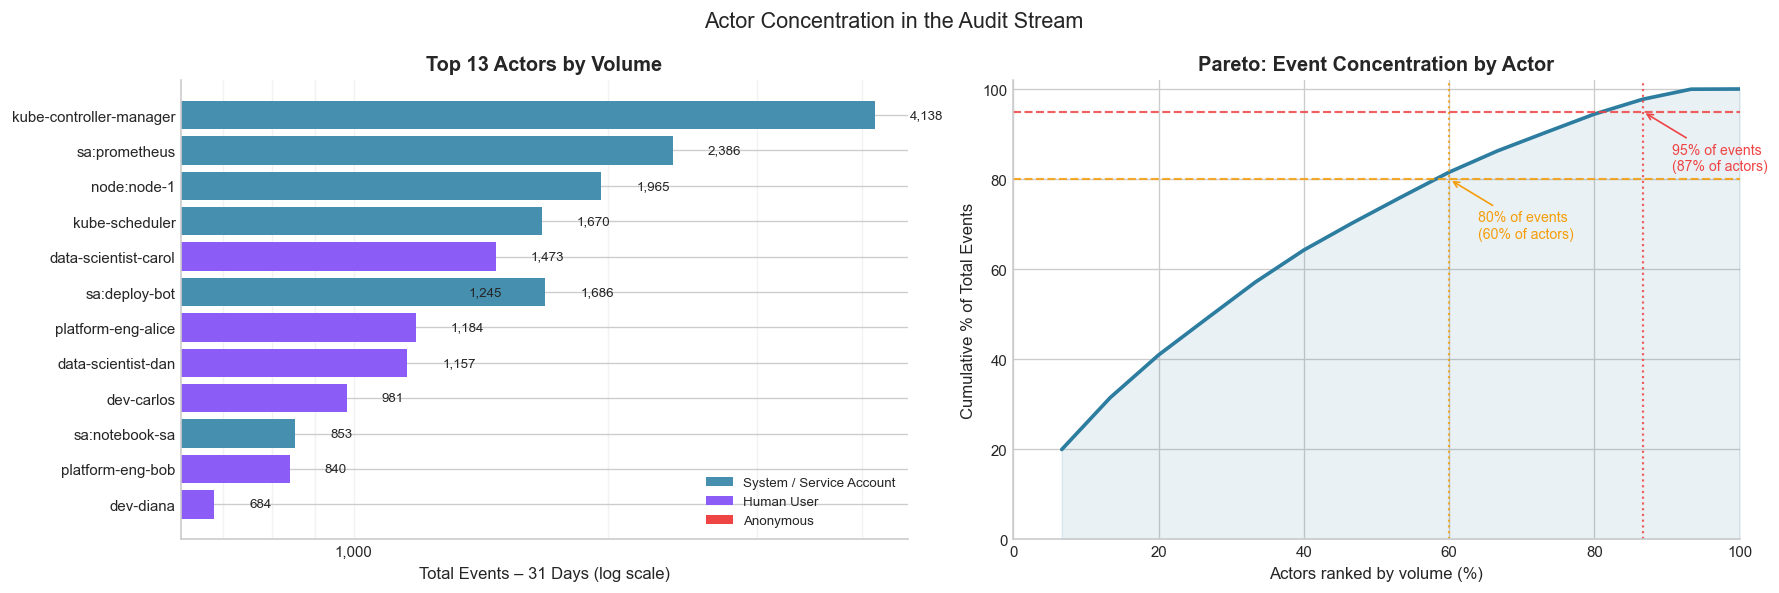

In [320]:
top_n      = 13
counts     = conc['actor_counts']
cum_pct    = counts.cumsum() / counts.sum() * 100
rank_pct   = np.arange(1, len(counts) + 1) / len(counts) * 100

top_actors = counts.head(top_n)
labels     = [shorten_actor_name(u) for u in top_actors.index]
bar_colors = [
    C_ALERT    if 'anonymous' in u else
    BLUES[3]   if u.startswith('system:') else
    C_CURRENT
    for u in top_actors.index
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Actor Concentration in the Audit Stream', fontsize=13)

bars = axes[0].barh(labels[::-1], top_actors.values[::-1],
                    color=bar_colors[::-1], edgecolor='none')
axes[0].set_xscale('log')
axes[0].xaxis.set_major_locator(mticker.LogLocator(base=10, numticks=8))
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10), numticks=50))
axes[0].xaxis.set_minor_formatter(mticker.NullFormatter())
axes[0].set_xlabel('Total Events \u2013 31 Days (log scale)')
axes[0].set_title(f'Top {top_n} Actors by Volume')
for bar, val in zip(bars, top_actors.values[::-1]):
    axes[0].text(val * 1.1, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=8)
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(facecolor=BLUES[3],  label='System / Service Account'),
    Patch(facecolor=C_CURRENT, label='Human User'),
    Patch(facecolor=C_ALERT,   label='Anonymous'),
], fontsize=8, loc='lower right')
axes[0].grid(axis='x', alpha=0.25, which='both')

axes[1].plot(rank_pct, cum_pct.values, color=BLUES[4], linewidth=2.2)
axes[1].fill_between(rank_pct, cum_pct.values, alpha=0.10, color=BLUES[4])
for target, color in [(80, C_WARN), (95, C_ALERT)]:
    idx     = (cum_pct.values >= target).argmax()
    x_cross = rank_pct[idx]
    axes[1].axhline(target,  color=color, linestyle='--', linewidth=1.3, alpha=0.85)
    axes[1].axvline(x_cross, color=color, linestyle=':',  linewidth=1.3, alpha=0.85)
    axes[1].annotate(
        f'{target}% of events\n({x_cross:.0f}% of actors)',
        xy=(x_cross, target), xytext=(x_cross + 4, target - 13),
        fontsize=8.5, color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=1)
    )
axes[1].set_xlabel('Actors ranked by volume (%)')
axes[1].set_ylabel('Cumulative % of Total Events')
axes[1].set_title('Pareto: Event Concentration by Actor')
axes[1].set_xlim(0, 100); axes[1].set_ylim(0, 102)

print(f"Top {conc['n_80']} actors ({conc['n_80']/conc['n_actors']*100:.0f}% of actors) generate 80% of all events")
print(f"Top {conc['n_95']} actors ({conc['n_95']/conc['n_actors']*100:.0f}% of actors) generate 95% of all events")
print("Implication: a single global threshold models system churn, not human behavior. Segment before baselining.")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'actor_pareto.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.2 Rare Events

Rare events (low-count verbs, resource types, or namespaces across the full observation window) are high-signal in security telemetry. An operation that happens only a handful of times is either infrequent by design (RBAC mutations, exec into pods) or was injected by something that doesn't look like normal cluster work.

The verb and resource distributions below include a rare-event scan. Anything below the count threshold is called out explicitly.


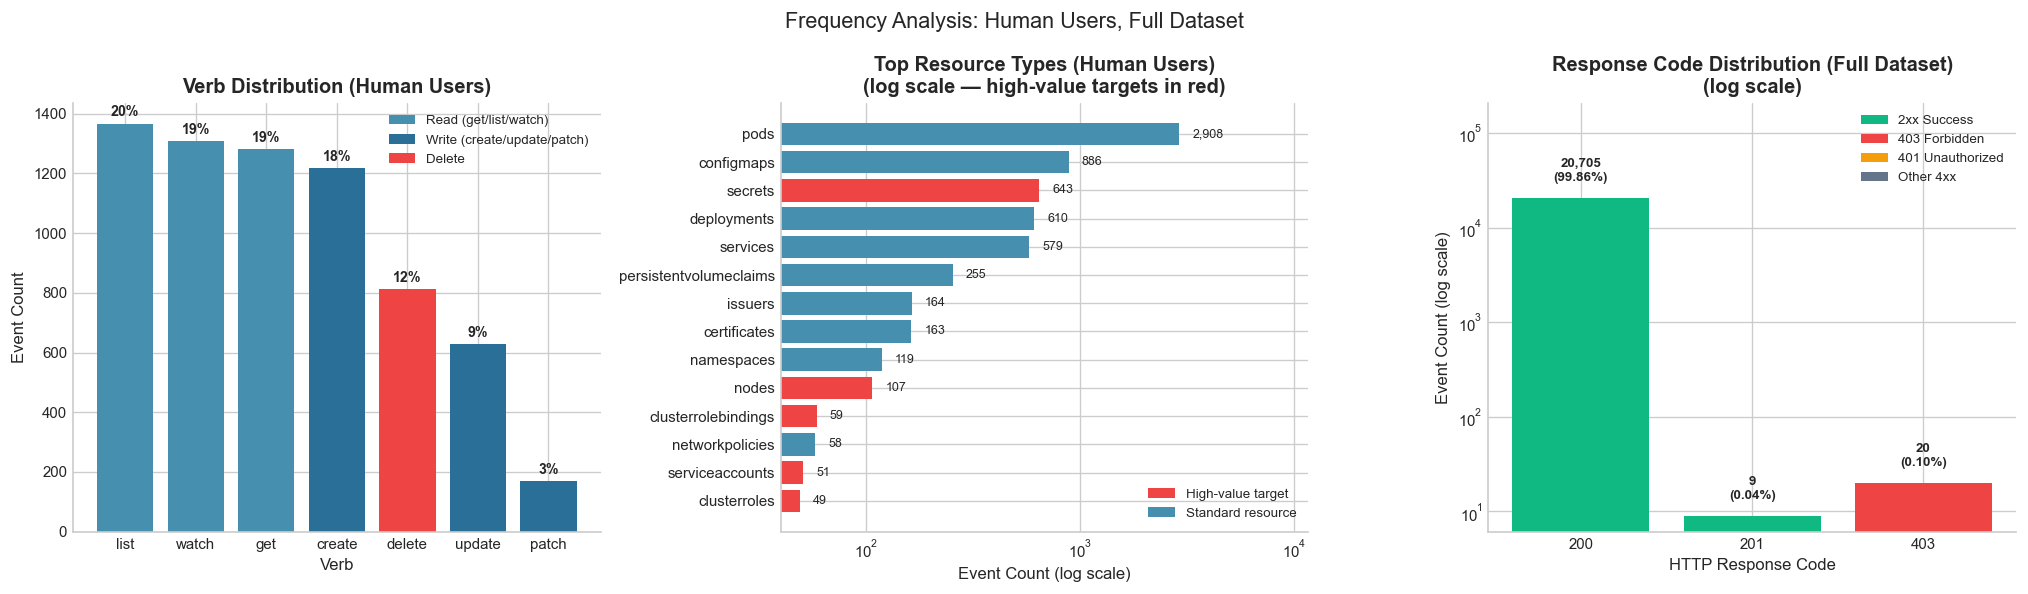

Read operations: 58.3% of human-user events
Forbidden (403) rate across full dataset: 0.10%


In [321]:
human = df[~df['user_username'].str.startswith('system:')]

verb_counts     = human['verb'].value_counts()
resource_counts = human['object_ref_resource'].dropna().value_counts().head(14)
resp_counts     = df['response_status_code'].value_counts().sort_index()

verb_color = lambda v: BLUES[3] if v in K8S_READ_VERBS else (BLUES[5] if v in K8S_WRITE_VERBS else (C_ALERT if v == 'delete' else C_SLATE))
resp_color = lambda c: C_OK if 200 <= c < 300 else (C_ALERT if c == 403 else (C_WARN if c == 401 else C_SLATE))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Frequency Analysis: Human Users, Full Dataset', fontsize=13)

v_colors = [verb_color(v) for v in verb_counts.index]
bars = axes[0].bar(verb_counts.index, verb_counts.values, color=v_colors, edgecolor='none')
for bar, cnt in zip(bars, verb_counts.values):
    pct = cnt / verb_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + verb_counts.max() * 0.01,
                 f'{pct:.0f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axes[0].set_title('Verb Distribution (Human Users)')
axes[0].set_xlabel('Verb'); axes[0].set_ylabel('Event Count')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(facecolor=BLUES[3], label='Read (get/list/watch)'),
    Patch(facecolor=BLUES[5], label='Write (create/update/patch)'),
    Patch(facecolor=C_ALERT,  label='Delete'),
], fontsize=8)

r_colors = [C_ALERT if r in K8S_HIGH_VALUE_RESOURCES else BLUES[3] for r in resource_counts.index]
axes[1].barh(resource_counts.index[::-1], resource_counts.values[::-1],
             color=r_colors[::-1], edgecolor='none')
axes[1].set_xscale('log')
axes[1].set_xlim(right=resource_counts.max() * 4)
for i, (res, val) in enumerate(zip(resource_counts.index[::-1], resource_counts.values[::-1])):
    axes[1].text(val * 1.15, i, f'{val:,}', va='center', fontsize=7.5)
axes[1].set_title('Top Resource Types (Human Users)\n(log scale \u2014 high-value targets in red)')
axes[1].set_xlabel('Event Count (log scale)')
axes[1].legend(handles=[
    Patch(facecolor=C_ALERT,  label='High-value target'),
    Patch(facecolor=BLUES[3], label='Standard resource'),
], fontsize=8, loc='lower right')

resp_colors = [resp_color(c) for c in resp_counts.index]
bars3 = axes[2].bar([str(c) for c in resp_counts.index], resp_counts.values,
                    color=resp_colors, edgecolor='none')
axes[2].set_yscale('log')
axes[2].set_ylim(top=resp_counts.max() * 10)
for bar, (code, cnt) in zip(bars3, resp_counts.items()):
    pct = cnt / resp_counts.sum() * 100
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.4,
                 f'{cnt:,}\n({pct:.2f}%)', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[2].set_title('Response Code Distribution (Full Dataset)\n(log scale)')
axes[2].set_xlabel('HTTP Response Code')
axes[2].set_ylabel('Event Count (log scale)')
axes[2].legend(handles=[
    Patch(facecolor=C_OK,    label='2xx Success'),
    Patch(facecolor=C_ALERT, label='403 Forbidden'),
    Patch(facecolor=C_WARN,  label='401 Unauthorized'),
    Patch(facecolor=C_SLATE, label='Other 4xx'),
], fontsize=8)

read_pct  = verb_counts.reindex(list(K8S_READ_VERBS)).sum() / verb_counts.sum() * 100
forbidden = resp_counts.get(403, 0) / resp_counts.sum() * 100
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'frequency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Read operations: {read_pct:.1f}% of human-user events")
print(f"Forbidden (403) rate across full dataset: {forbidden:.2f}%")


In [322]:
RARE_THRESHOLD = 100

human = df[~df['user_username'].str.startswith('system:')]
for col, label in [('verb','Verbs'), ('object_ref_resource','Resource types'), ('object_ref_namespace','Namespaces')]:
    rare = get_rare_events(human[col].dropna(), threshold=RARE_THRESHOLD)
    print(f"Rare {label} (< {RARE_THRESHOLD} events, human actors only):")
    if rare.empty:
        print("  (none below threshold)")
    else:
        display(rare)
    print()


Rare Verbs (< 100 events, human actors only):
  (none below threshold)

Rare Resource types (< 100 events, human actors only):


,value,count
0,clusterrolebindings,59
1,networkpolicies,58
2,serviceaccounts,51
3,clusterroles,49
4,podsecuritypolicies,49
5,rolebindings,44
6,roles,39



Rare Namespaces (< 100 events, human actors only):


,value,count
0,sandbox,70
1,default,58


### 2.3 Temporal Patterns

When activity occurs is as important as what activity occurs. The day-of-week / hour heatmap reveals the cluster's natural rhythm: peak business hours, weekend drop-offs, quiet overnight windows. Deviations from that rhythm, specifically activity at unusual hours from actors who are normally quiet then, are one of the cheapest signals to compute.


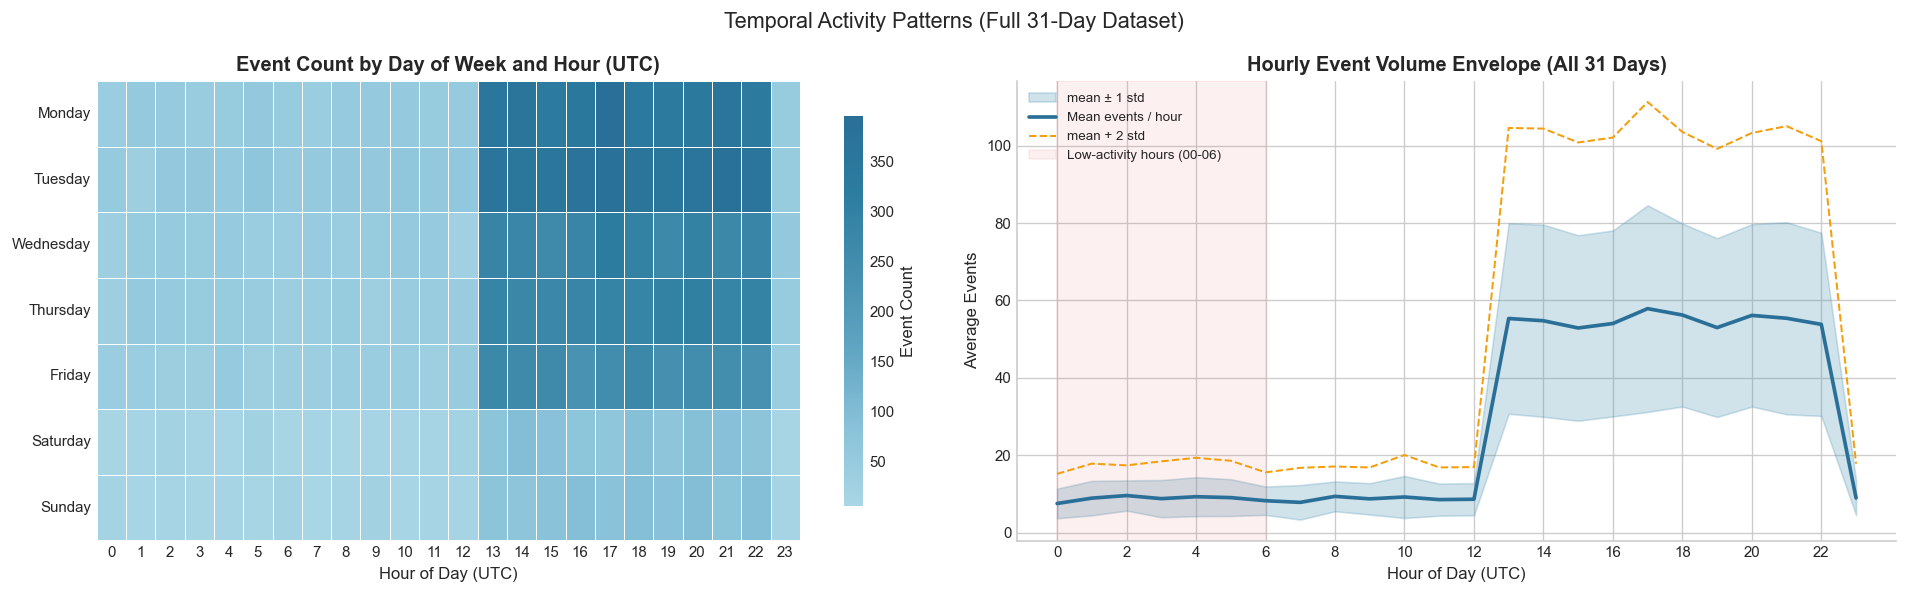

Mean 00-05 UTC: 9/hr  |  Mean 13-22 UTC: 55/hr  |  Ratio: 6.2x


In [323]:
tp = compute_temporal_patterns(df)
heatmap_data = tp['heatmap_data']
hourly_stats = tp['hourly_stats']

blues_cmap = mcolors.LinearSegmentedColormap.from_list('custom_blues', BLUES)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Temporal Activity Patterns (Full 31-Day Dataset)', fontsize=13)

sns.heatmap(heatmap_data, ax=axes[0], cmap=blues_cmap,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Event Count', 'shrink': 0.85}, annot=False)
axes[0].set_title('Event Count by Day of Week and Hour (UTC)')
axes[0].set_xlabel('Hour of Day (UTC)'); axes[0].set_ylabel('')

h, mean_vals, std_vals = (hourly_stats.index.values,
                          hourly_stats['mean'].values,
                          hourly_stats['std'].values)
axes[1].fill_between(h, mean_vals - std_vals, mean_vals + std_vals,
                     alpha=0.25, color=BLUES[3], label='mean \u00b1 1 std')
axes[1].plot(h, mean_vals, color=BLUES[5], linewidth=2.2, label='Mean events / hour')
axes[1].plot(h, mean_vals + 2 * std_vals, color=C_WARN, linewidth=1.2,
             linestyle='--', label='mean + 2 std')
axes[1].axvspan(0, 6, alpha=0.08, color=C_ALERT, label='Low-activity hours (00-06)')
axes[1].set_xlabel('Hour of Day (UTC)'); axes[1].set_ylabel('Average Events')
axes[1].set_title('Hourly Event Volume Envelope (All 31 Days)')
axes[1].set_xticks(range(0, 24, 2)); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'activity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean 00-05 UTC: {tp['low_hour_mean']:.0f}/hr  |  "
      f"Mean 13-22 UTC: {tp['biz_hour_mean']:.0f}/hr  |  "
      f"Ratio: {tp['biz_hour_mean']/tp['low_hour_mean']:.1f}x")


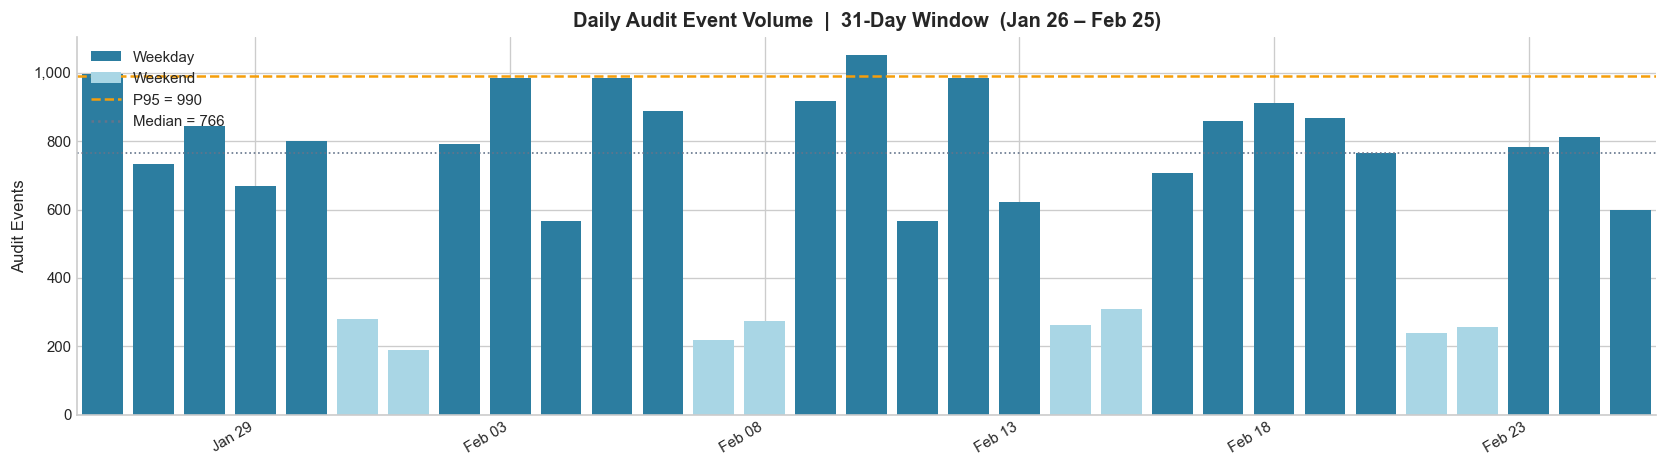

Weekday median: 813  |  Weekend median: 260  |  Ratio: 3.1x
P95 threshold: 990 events/day  |  Median: 766 events/day
No day dramatically exceeds the P95 ceiling — aggregate daily volume is stable across the window.


In [324]:
daily_volume = df.groupby('date').size().reset_index(name='events')
daily_volume['date']       = pd.to_datetime(daily_volume['date'])
daily_volume['is_weekend'] = daily_volume['date'].dt.dayofweek >= 5

p95 = float(np.percentile(daily_volume['events'], 95))
p50 = float(np.percentile(daily_volume['events'], 50))

bar_colors = [C_WKEND if row['is_weekend'] else C_BASELINE
              for _, row in daily_volume.iterrows()]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily_volume['date'], daily_volume['events'],
       color=bar_colors, width=0.8, edgecolor='none')

ax.axhline(p95, color=C_WARN,  linewidth=1.5, linestyle='--')
ax.axhline(p50, color=C_SLATE, linewidth=1.0, linestyle=':')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xticks(rotation=30, ha='right')
ax.set_ylabel('Audit Events')
ax.set_title('Daily Audit Event Volume  |  31-Day Window  (Jan 26 – Feb 25)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(
    daily_volume['date'].min() - pd.Timedelta(days=0.5),
    daily_volume['date'].max() + pd.Timedelta(days=0.5)
)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=C_BASELINE, label='Weekday'),
    Patch(facecolor=C_WKEND,    label='Weekend'),
    plt.Line2D([0],[0], color=C_WARN,  linestyle='--', label=f'P95 = {p95:,.0f}'),
    plt.Line2D([0],[0], color=C_SLATE, linestyle=':',  label=f'Median = {p50:,.0f}'),
], fontsize=9, loc='upper left')
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'event_volume_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

wkday_med = daily_volume[~daily_volume['is_weekend']]['events'].median()
wkend_med = daily_volume[ daily_volume['is_weekend']]['events'].median()
print(f"Weekday median: {wkday_med:,.0f}  |  Weekend median: {wkend_med:,.0f}  "
      f"|  Ratio: {wkday_med/wkend_med:.1f}x")
print(f"P95 threshold: {p95:,.0f} events/day  |  Median: {p50:,.0f} events/day")
print("No day dramatically exceeds the P95 ceiling — aggregate daily volume is stable across the window.")


The bar chart surfaces two things immediately. Weekend days (light blue) run at roughly half the weekday volume, expected for a cluster used primarily by a daytime engineering team. Weekday volume is stable across the 31-day window, clustering between the median and P95 reference lines with no dramatic outlier days.

That stability is both reassuring and a limitation. Reassuring because a brute-force scan or deployment storm would stand out immediately. A limitation because a sophisticated actor operating within the normal weekday volume band produces no visible bar on this chart. Volume-only alerting would not fire. Sections 5 and 6 shift the focus from *how much* to *what kind*, using behavioral baselining to detect actors who stay within volume bounds but drift from their established namespace, resource, and verb footprint.


### 2.4 Verb x Resource Frequency Matrix

Operations don't occur in isolation. Attackers combine specific verbs with high-value resources. The left panel maps every `(verb, resource_type)` pair for human users: **white = zero**, **red = high volume** (log-scaled so rare cells remain visible). The right panel ranks the top 15 pairs by raw count, flagging high-risk combinations in red.

Recon pairs to watch: `list x secrets`, `exec x pods`, `create x clusterrolebindings`. These are rare in normal operations; any non-trivial count warrants follow-up.

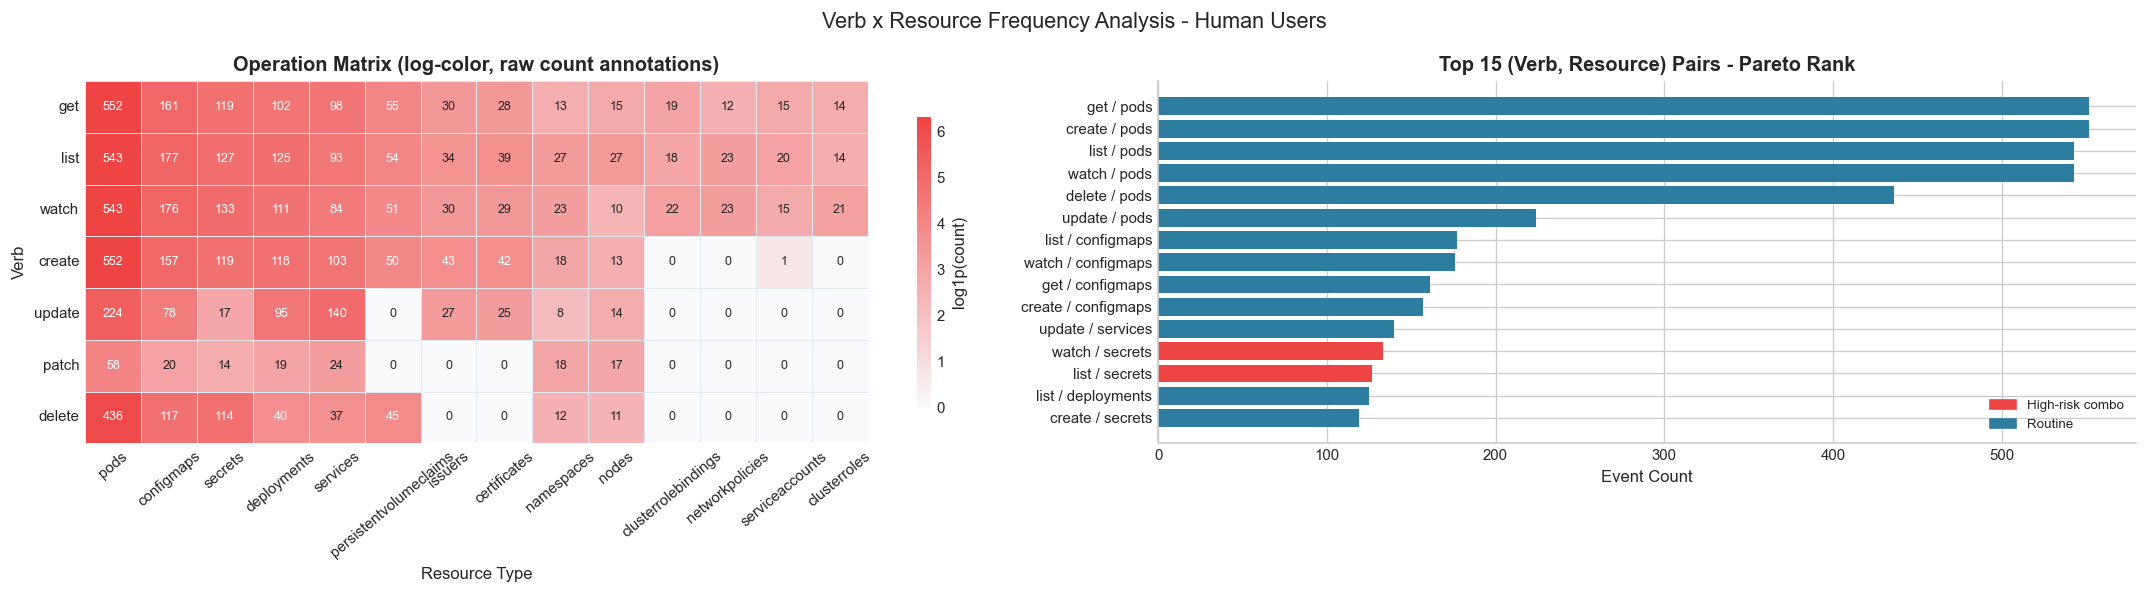

In [325]:
human = df[~df['user_username'].str.startswith('system:')]

vr = (human
      .dropna(subset=['object_ref_resource'])
      .groupby(['verb', 'object_ref_resource'])
      .size()
      .unstack(fill_value=0))

verb_order = ['get', 'list', 'watch', 'create', 'update', 'patch', 'delete',
              'exec', 'portforward', 'impersonate']
vr = vr.reindex([v for v in verb_order if v in vr.index])
top_resources = human['object_ref_resource'].dropna().value_counts().head(14).index
vr = vr[[c for c in top_resources if c in vr.columns]]

# Pareto ranking — top 15 (verb, resource) pairs
pairs = (human
         .dropna(subset=['object_ref_resource'])
         .groupby(['verb', 'object_ref_resource'])
         .size()
         .sort_values(ascending=False)
         .head(15))
pair_labels = [f'{v} / {r}' for v, r in pairs.index]

HIGH_VALUE_COMBOS = {
    ('list','secrets'), ('get','secrets'), ('watch','secrets'),
    ('exec','pods'), ('portforward','pods'),
    ('create','clusterrolebindings'), ('delete','clusterrolebindings'),
    ('create','clusterroles'), ('update','clusterroles'),
    ('impersonate', None),
}
pair_colors = [C_ALERT if tuple(p) in HIGH_VALUE_COMBOS else BLUES[4] for p in pairs.index]

two_color_vr = mcolors.LinearSegmentedColormap.from_list('vr_heat', ['#f8fafc', C_ALERT])
log_vr = np.log1p(vr)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Verb x Resource Frequency Analysis - Human Users', fontsize=13)

sns.heatmap(log_vr, ax=axes[0], cmap=two_color_vr,
            annot=vr.values, fmt='g', annot_kws={'size': 7.5},
            linewidths=0.3, linecolor='#e2e8f0',
            cbar_kws={'label': 'log1p(count)', 'shrink': 0.8})
axes[0].set_title('Operation Matrix (log-color, raw count annotations)')
axes[0].set_xlabel('Resource Type')
axes[0].set_ylabel('Verb')
axes[0].tick_params(axis='x', rotation=40, labelsize=9)
axes[0].tick_params(axis='y', rotation=0,  labelsize=9)

axes[1].barh(pair_labels[::-1], pairs.values[::-1], color=pair_colors[::-1], edgecolor='none')
axes[1].set_xlabel('Event Count')
axes[1].set_title('Top 15 (Verb, Resource) Pairs - Pareto Rank')
axes[1].tick_params(axis='y', labelsize=9)
axes[1].legend(handles=[
    plt.Rectangle((0,0),1,1, color=C_ALERT, label='High-risk combo'),
    plt.Rectangle((0,0),1,1, color=BLUES[4], label='Routine'),
], fontsize=8)

fig.tight_layout()
plt.savefig(OUTPUT_DIR / 'verb_resource_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Frequency observation:** Read operations dominate as expected: `get` and `list` across pods, configmaps, and deployments account for most of the matrix volume. The cells to scrutinize are the ones that should be rare but show non-zero counts: `list/secrets`, `get/secrets`, and any RBAC-related combinations. The Pareto panel confirms which pairs drive the bulk of events and which appear only a handful of times across 31 days. Those low-count, high-sensitivity pairs are what Sections 4 and 6 will follow up on.

### 2.5 User x Namespace Access Matrix

The namespace dimension reveals each actor's operational footprint across the cluster. Expected reach by role: data scientists should access 2 namespaces (ml-pipelines, jupyter-notebooks); developers should access 2 namespaces per team; platform engineers and security accounts are expected to reach broadly for their function. An actor appearing in namespaces outside their expected role is a natural frequency signal; no threshold required.

Heatmap: **white = no access**, **purple = heavy activity** (log-scaled, raw counts annotated). Rows sorted by namespace breadth descending.

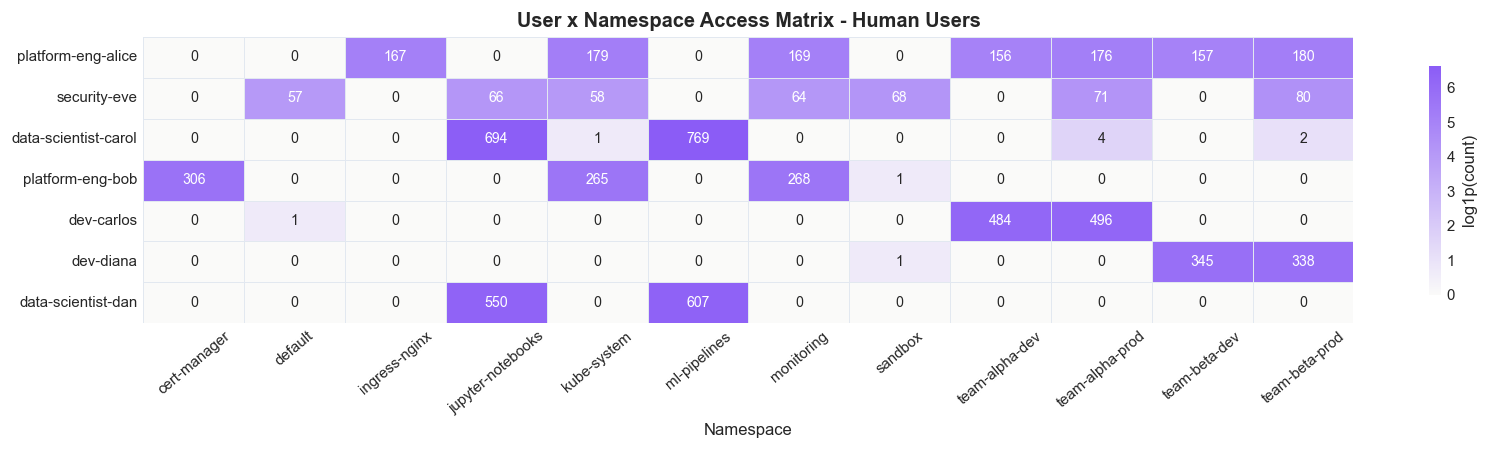

Distinct namespaces accessed per actor:


,distinct_namespaces
platform-eng-alice,7
security-eve,7
data-scientist-carol,5
platform-eng-bob,4
dev-carlos,3
dev-diana,3
data-scientist-dan,2


In [326]:
human = df[~df['user_username'].str.startswith('system:')]

un = (human
      .dropna(subset=['object_ref_namespace'])
      .groupby(['user_username', 'object_ref_namespace'])
      .size()
      .unstack(fill_value=0))
un.index = [shorten_actor_name(u) for u in un.index]
un = un.loc[un.gt(0).sum(axis=1).sort_values(ascending=False).index]

two_color_ns = mcolors.LinearSegmentedColormap.from_list('ns_heat', ['#fafaf9', C_CURRENT])
log_un = np.log1p(un)

fig, ax = plt.subplots(figsize=(14, max(3.5, 0.55 * len(un))))
sns.heatmap(log_un, ax=ax, cmap=two_color_ns,
            annot=un.values, fmt='g', annot_kws={'size': 8.5},
            linewidths=0.3, linecolor='#e2e8f0',
            cbar_kws={'label': 'log1p(count)', 'shrink': 0.8})
ax.set_title('User x Namespace Access Matrix - Human Users')
ax.set_xlabel('Namespace')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / 'user_namespace_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

ns_breadth = un.gt(0).sum(axis=1).sort_values(ascending=False)
print('Distinct namespaces accessed per actor:')
display(ns_breadth.to_frame('distinct_namespaces'))

**Frequency observation:** `data-scientist-carol` accesses 5 distinct namespaces across the window: her expected ml-pipelines (791 events) and jupyter-notebooks (780), but also kube-system (1 event), team-alpha-prod (4), and team-beta-prod (2). Her functional peer `data-scientist-dan` shows a clean 2-namespace footprint. This asymmetry is visible from raw event counts with no statistical modeling. Platform engineers and security-eve showing 7 namespaces is consistent with their roles; a data scientist at 5 is not.

### 2.6 Rare Resource Access: Verb and Actor Breakdown

Section 2.2 flagged seven resource types with fewer than 100 events over 31 days: serviceaccounts, clusterroles, networkpolicies, roles, rolebindings, podsecuritypolicies, and clusterrolebindings. These are RBAC and network-policy primitives; resources that healthy clusters rarely modify, and that attackers target during privilege escalation.

The left panel shows **how** these resources were accessed (verb breakdown). The right panel shows **who** accessed them. Normal expectation: platform engineering and security accounts dominate. Deviations from that expectation stand out immediately.

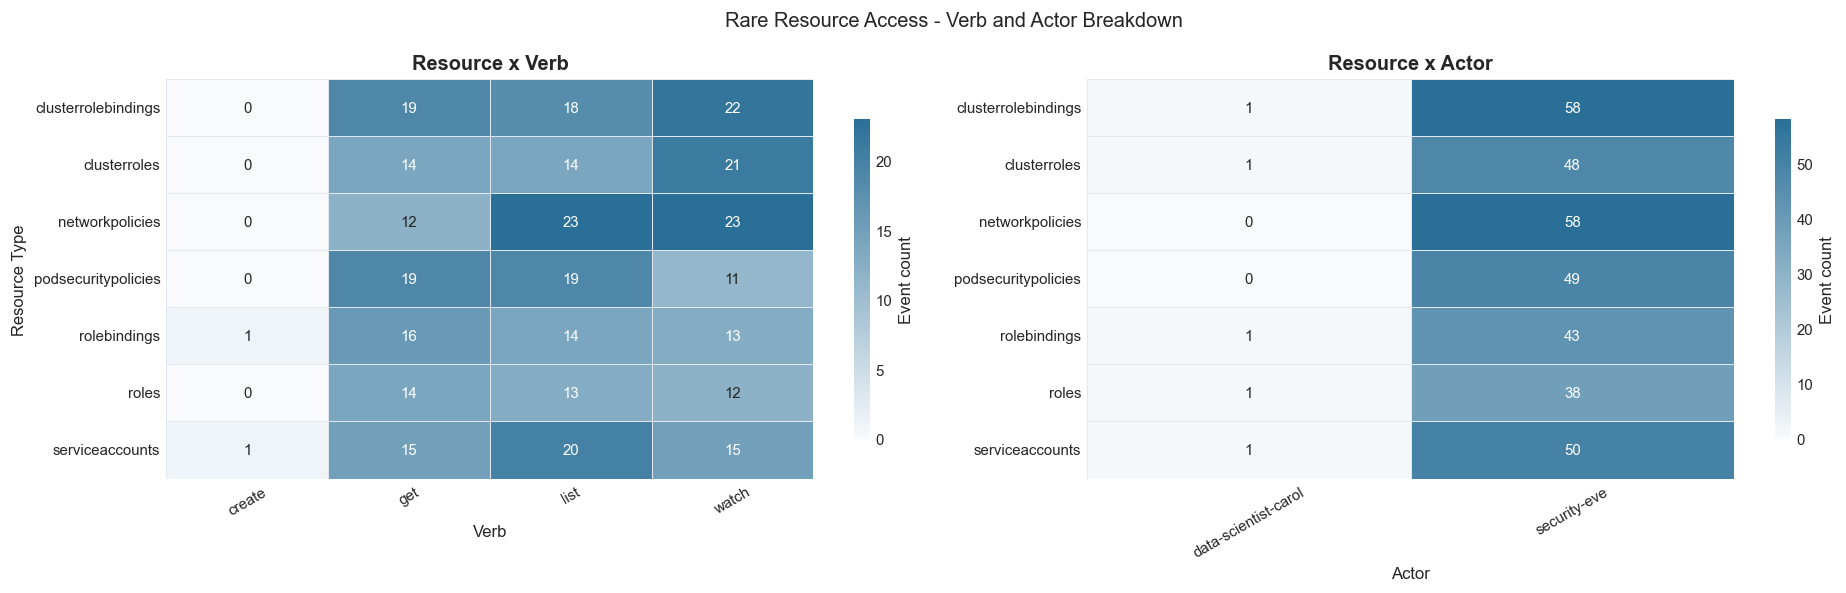

In [327]:
RARE_THRESHOLD = 100  # consistent with Section 2.2

human = df[~df['user_username'].str.startswith('system:')]
rare_res = (human['object_ref_resource']
            .dropna()
            .value_counts()
            .pipe(lambda s: s[s < RARE_THRESHOLD])
            .index.tolist())

rare = human[human['object_ref_resource'].isin(rare_res)]

rv = (rare.groupby(['object_ref_resource', 'verb'])
      .size().unstack(fill_value=0))
ra = (rare.groupby(['object_ref_resource', 'user_username'])
      .size().unstack(fill_value=0))
ra.columns = [shorten_actor_name(u) for u in ra.columns]

two_color_rare = mcolors.LinearSegmentedColormap.from_list('rare_heat', ['#f8fafc', BLUES[5]])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Rare Resource Access - Verb and Actor Breakdown', fontsize=12)

sns.heatmap(rv, ax=axes[0], cmap=two_color_rare,
            annot=True, fmt='g', annot_kws={'size': 9},
            linewidths=0.4, linecolor='#e2e8f0',
            cbar_kws={'label': 'Event count', 'shrink': 0.8})
axes[0].set_title('Resource x Verb')
axes[0].set_xlabel('Verb')
axes[0].set_ylabel('Resource Type')
axes[0].tick_params(axis='x', rotation=30, labelsize=9)
axes[0].tick_params(axis='y', rotation=0,  labelsize=9)

sns.heatmap(ra, ax=axes[1], cmap=two_color_rare,
            annot=True, fmt='g', annot_kws={'size': 9},
            linewidths=0.4, linecolor='#e2e8f0',
            cbar_kws={'label': 'Event count', 'shrink': 0.8})
axes[1].set_title('Resource x Actor')
axes[1].set_xlabel('Actor')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30, labelsize=9)
axes[1].tick_params(axis='y', rotation=0,  labelsize=9)

fig.tight_layout()
plt.savefig(OUTPUT_DIR / 'rare_resource_access.png', dpi=150, bbox_inches='tight')
plt.show()

**Frequency observation:** `security-eve` accounts for the large majority of events across all seven rare resource types, consistent with a security engineer auditing cluster permissions. The exception: `data-scientist-carol` has a small number of events in clusterrolebindings, clusterroles, rolebindings, roles, and serviceaccounts, including `create` operations on serviceaccounts and rolebindings. A data scientist has no functional need to create RBAC primitives. This surfaces entirely from raw frequency counts, with no labeled attack data used.

### 2.7 Actor Footprint Summary

A scatter of namespace breadth vs. resource diversity, sized by event volume, gives a spatial fingerprint of each actor's operational scope. Actors that cluster with their functional peers are behaving predictably. An actor displaced from their peer cluster has a broader reach than their role requires.

The summary table provides the underlying counts for direct comparison.

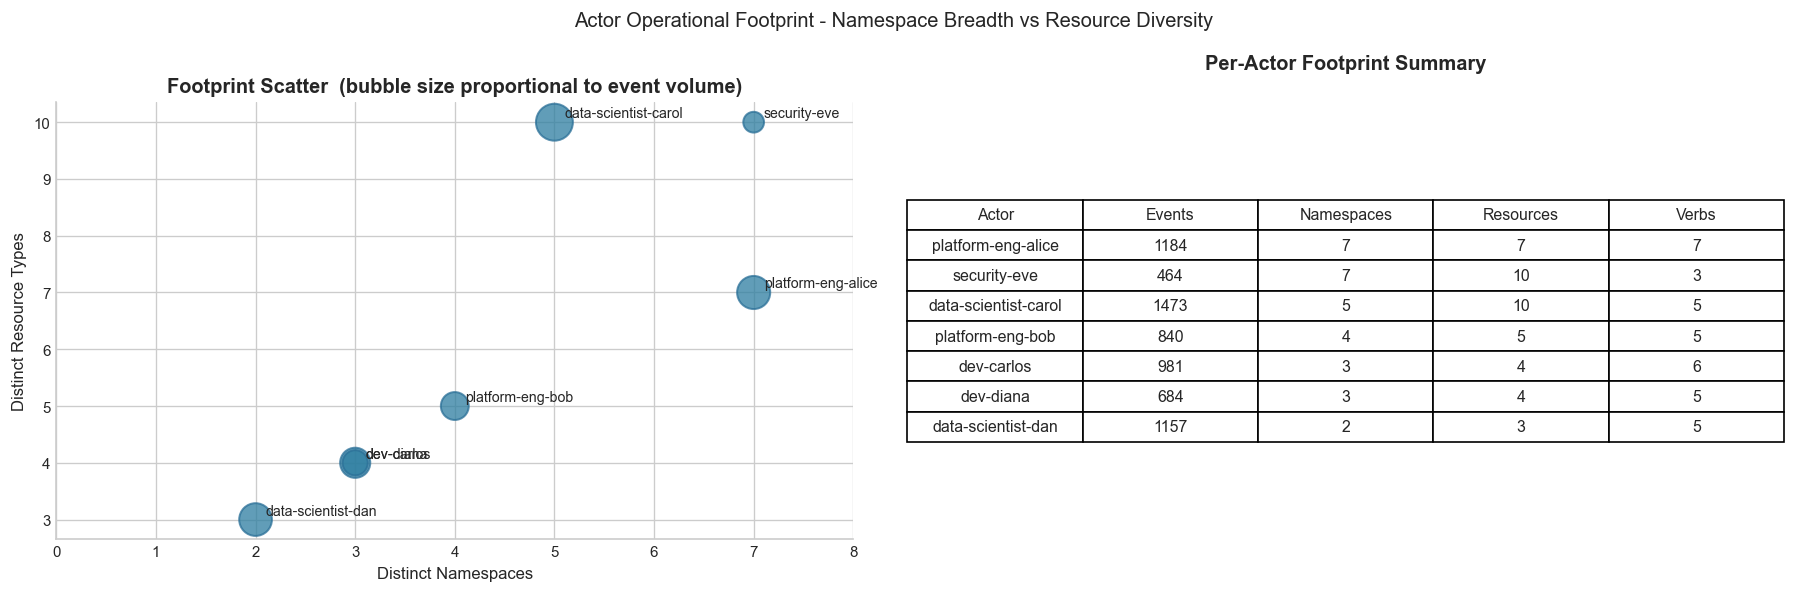

In [328]:
human = df[~df['user_username'].str.startswith('system:')]

stats = human.groupby('user_username').agg(
    total_events     = ('verb',                'count'),
    distinct_verbs   = ('verb',                'nunique'),
    distinct_resources = ('object_ref_resource', 'nunique'),
    distinct_namespaces = ('object_ref_namespace', 'nunique'),
).reset_index()
stats['actor'] = stats['user_username'].apply(shorten_actor_name)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Actor Operational Footprint - Namespace Breadth vs Resource Diversity', fontsize=12)

sc = axes[0].scatter(
    stats['distinct_namespaces'],
    stats['distinct_resources'],
    s=stats['total_events'] / 3,
    color=C_BASELINE, alpha=0.75, edgecolors=BLUES[5], linewidths=1.2)
for _, row in stats.iterrows():
    axes[0].annotate(row['actor'],
                     (row['distinct_namespaces'], row['distinct_resources']),
                     textcoords='offset points', xytext=(6, 3), fontsize=8.5)
axes[0].set_xlabel('Distinct Namespaces')
axes[0].set_ylabel('Distinct Resource Types')
axes[0].set_title('Footprint Scatter  (bubble size proportional to event volume)')
axes[0].set_xticks(range(0, int(stats['distinct_namespaces'].max()) + 2))

axes[1].axis('off')
tbl_data = (stats
            .sort_values('distinct_namespaces', ascending=False)
            [['actor','total_events','distinct_namespaces','distinct_resources','distinct_verbs']]
            .values.tolist())
col_labels = ['Actor', 'Events', 'Namespaces', 'Resources', 'Verbs']
tbl = axes[1].table(cellText=tbl_data, colLabels=col_labels,
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1.1, 1.6)
axes[1].set_title('Per-Actor Footprint Summary', fontweight='bold', pad=20)

fig.tight_layout()
plt.savefig(OUTPUT_DIR / 'actor_footprint.png', dpi=150, bbox_inches='tight')
plt.show()

**Frequency observation:** Carol plots to the right of her peer group in the namespace dimension: 5 namespaces vs. Dan's 2, and 10 distinct resource types vs. Dan's 3. Alice (7 namespaces) and Eve (7 namespaces) show broad footprints consistent with their platform and security roles. Carol's position in the scatter is inconsistent with a data scientist profile and matches the namespace drift already visible in 2.5.

## Section 3: Data Distribution and Stats

Understanding the *shape* of the data determines which statistical methods are valid. Two mistakes are common in detection engineering: applying mean ± std to data that isn't Gaussian (upper bound is correct but lower bound can go negative), and setting a single global threshold on data with wildly different per-actor activity levels. This section characterizes both problems, then derives the methods that actually fit the data.


### 3a: Distribution Analysis

Every detection threshold is an implicit claim about a distribution. When you say "alert when daily event volume exceeds 800," you are claiming that 800 is meaningfully above normal. Whether that is true depends on what the distribution actually looks like.

Kubernetes audit log volume has predictable structure: lower on weekends, higher on business days, with occasional spikes from deployments or maintenance. The question is whether the variation around that structure is Gaussian enough that mean and standard deviation give useful threshold units, or whether the distribution has enough skew and multimodality that we need robust estimators like MAD or percentile-based thresholds.

At the per-actor per-hour granularity needed for behavioral detections, a second property emerges: **overdispersion**. Most actors generate zero events in most hours, and when they do generate events, the count variance far exceeds what a Poisson distribution predicts. This matters because Poisson is the natural model for count data, but using it here produces systematically wrong thresholds.

The cells below characterize both distribution shapes — daily aggregate and per-actor per-hour — with explicit method justification in 3b.

,Value
Stat,
Days in window,31
Mean events/day,669
Std dev,274
Median,766
MAD,166
P95,990
P99,"1,035"
Shapiro-Wilk p,0.0035 (rejects normality — prefer P95/MAD ov...


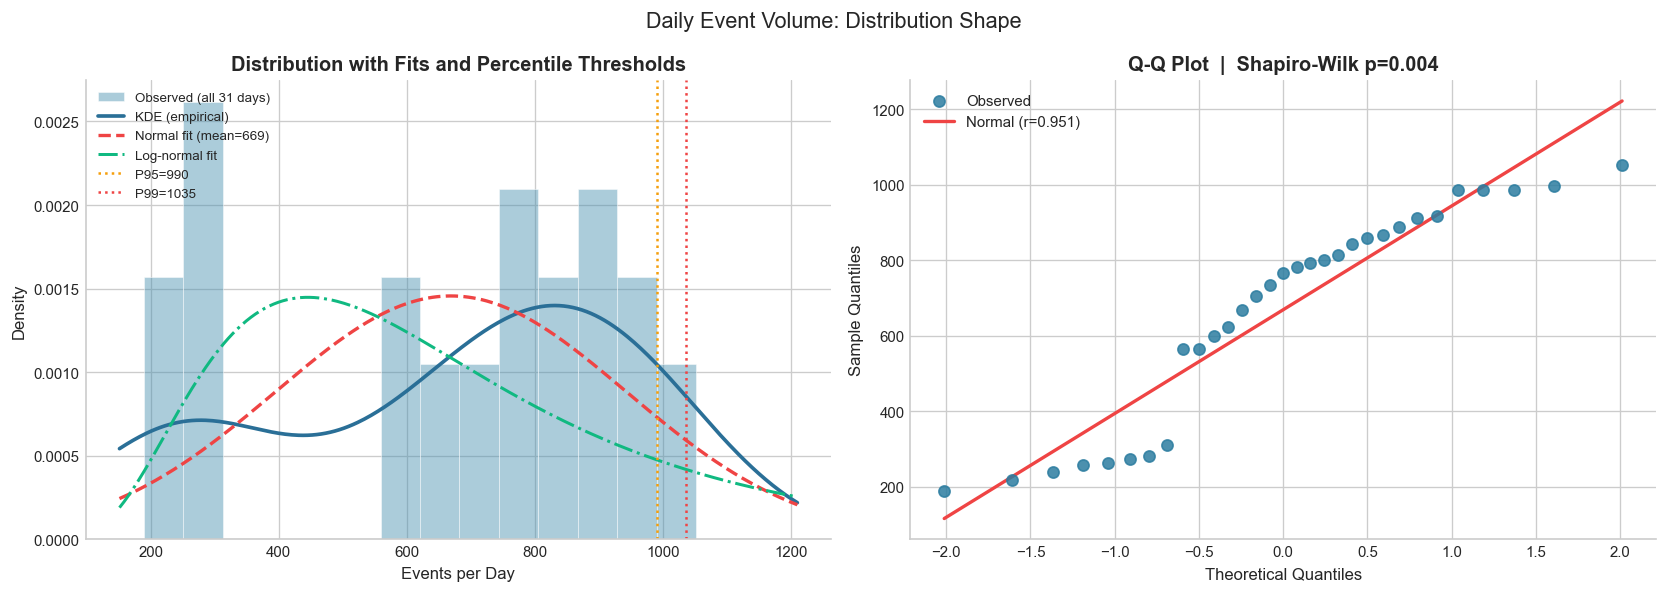

Normal lower bound = mean - 2σ = 121  ← would go negative on smaller clusters. P95 respects the zero bound.
Shapiro-Wilk p=0.0035: distribution is not perfectly normal — use P95 or MAD-based thresholds.


In [329]:
vd = analyze_volume_distribution(daily_volume['events'])
display(vd['stats_table'])

from scipy import stats as sp_stats
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Daily Event Volume: Distribution Shape', fontsize=13)

axes[0].hist(vd['data'], bins=14, density=True,
             color=BLUES[3], alpha=0.45, edgecolor='white', linewidth=0.6,
             label='Observed (all 31 days)')
axes[0].plot(vd['x_range'], vd['kde'](vd['x_range']),
             color=BLUES[5], linewidth=2.2, label='KDE (empirical)')
axes[0].plot(vd['x_range'], sp_stats.norm.pdf(vd['x_range'], vd['mu'], vd['sigma']),
             color=C_ALERT, linewidth=2, linestyle='--',
             label=f"Normal fit (mean={vd['mu']:.0f})")
axes[0].plot(vd['x_range'],
             sp_stats.lognorm.pdf(vd['x_range'], vd['ln_shape'], vd['ln_loc'], vd['ln_scale']),
             color=C_OK, linewidth=1.8, linestyle='-.', label='Log-normal fit')
axes[0].axvline(vd['pcts'][95], color=C_WARN,  linewidth=1.5, linestyle=':', label=f"P95={vd['pcts'][95]:.0f}")
axes[0].axvline(vd['pcts'][99], color=C_ALERT, linewidth=1.5, linestyle=':', label=f"P99={vd['pcts'][99]:.0f}")
axes[0].set_xlabel('Events per Day'); axes[0].set_ylabel('Density')
axes[0].set_title('Distribution with Fits and Percentile Thresholds')
axes[0].legend(fontsize=8)

(osm, osr), (slope, intercept, r) = sp_stats.probplot(vd['data'], dist='norm')
axes[1].scatter(osm, osr, color=BLUES[4], s=45, alpha=0.85, zorder=3, label='Observed')
fit_line = slope * np.array([min(osm), max(osm)]) + intercept
axes[1].plot([min(osm), max(osm)], fit_line, color=C_ALERT, linewidth=2, label=f'Normal (r={r:.3f})')
axes[1].set_xlabel('Theoretical Quantiles'); axes[1].set_ylabel('Sample Quantiles')
axes[1].set_title(f"Q-Q Plot  |  Shapiro-Wilk p={vd['shapiro_p']:.3f}")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'volume_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Normal lower bound = mean - 2\u03c3 = {vd['mu'] - 2*vd['sigma']:,.0f}  "
      "\u2190 would go negative on smaller clusters. P95 respects the zero bound.")
print(f"Shapiro-Wilk p={vd['shapiro_p']:.4f}: "
      + ('distribution is close to normal.' if vd['is_normal']
         else 'distribution is not perfectly normal \u2014 use P95 or MAD-based thresholds.'))


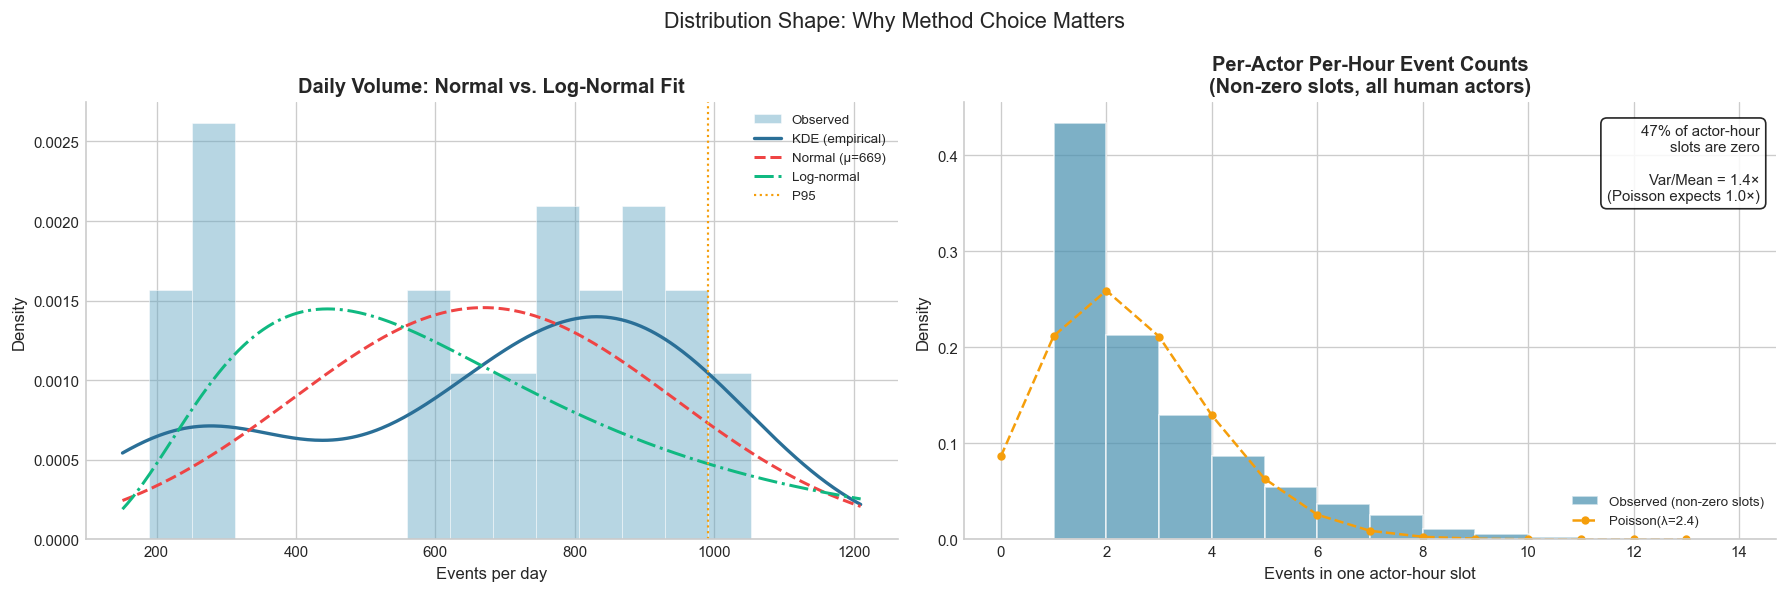

Per-actor per-hour: 47% of slots are zero (zero-inflated).
Non-zero slot variance/mean = 1.4× (overdispersion; Poisson assumes 1.0×).
IQR avoids the Poisson assumption entirely — rank statistics are immune to overdispersion.


In [330]:
full_grid = build_actor_hour_grid(df)
disp      = analyze_hourly_overdispersion(full_grid)

from scipy import stats as sp_stats
nonzero  = disp['nonzero']
k_max    = min(int(nonzero.max()) + 1, 25)
k_vals   = np.arange(0, k_max)
vol_vals = daily_volume['events'].values
mu_n, sig_n = sp_stats.norm.fit(vol_vals)
ln_shape, ln_loc, ln_scale = sp_stats.lognorm.fit(vol_vals, floc=0)
x_vol    = np.linspace(vol_vals.min() * 0.80, vol_vals.max() * 1.15, 300)
kde_vol  = sp_stats.gaussian_kde(vol_vals, bw_method='silverman')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Distribution Shape: Why Method Choice Matters', fontsize=13)

axes[0].hist(vol_vals, bins=14, density=True,
             color=BLUES[2], alpha=0.45, edgecolor='white', linewidth=0.6, label='Observed')
axes[0].plot(x_vol, kde_vol(x_vol), color=BLUES[5], linewidth=2.0, label='KDE (empirical)')
axes[0].plot(x_vol, sp_stats.norm.pdf(x_vol, mu_n, sig_n),
             color=C_ALERT, linewidth=1.8, linestyle='--', label=f'Normal (\u03bc={mu_n:,.0f})')
axes[0].plot(x_vol, sp_stats.lognorm.pdf(x_vol, ln_shape, ln_loc, ln_scale),
             color=C_OK, linewidth=1.8, linestyle='-.', label='Log-normal')
axes[0].axvline(np.percentile(vol_vals, 95), color=C_WARN, linewidth=1.3, linestyle=':', label='P95')
axes[0].set_title('Daily Volume: Normal vs. Log-Normal Fit')
axes[0].set_xlabel('Events per day'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

axes[1].hist(nonzero, bins=range(1, k_max + 1), density=True,
             color=BLUES[3], alpha=0.7, edgecolor='white', label='Observed (non-zero slots)')
axes[1].plot(k_vals, sp_stats.poisson.pmf(k_vals, disp['mean_nz']),
             'o--', color=C_WARN, markersize=4, linewidth=1.5,
             label=f"Poisson(\u03bb={disp['mean_nz']:.1f})")
axes[1].set_title('Per-Actor Per-Hour Event Counts\n(Non-zero slots, all human actors)')
axes[1].set_xlabel('Events in one actor-hour slot'); axes[1].set_ylabel('Density')
axes[1].text(0.98, 0.95,
    f"{disp['pct_zero']:.0f}% of actor-hour\nslots are zero\n\nVar/Mean = {disp['disp_ratio']:.1f}\u00d7\n(Poisson expects 1.0\u00d7)",
    transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribution_fitting.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Per-actor per-hour: {disp['pct_zero']:.0f}% of slots are zero (zero-inflated).")
print(f"Non-zero slot variance/mean = {disp['disp_ratio']:.1f}\u00d7 (overdispersion; Poisson assumes 1.0\u00d7).")
print('IQR avoids the Poisson assumption entirely \u2014 rank statistics are immune to overdispersion.')


In [331]:
user_baselines, user_daily = build_per_actor_baseline(df)

print("Per-user daily event volume \u2014 median and MAD are robust to single-day spikes:")
display(user_baselines.set_index('user_username'))

outlier_mask, mod_z = detect_outliers_mad(user_daily['daily_count'], threshold=3.5)
user_daily = user_daily.copy()
user_daily['modified_z'] = mod_z.round(2)
user_daily['is_outlier']  = outlier_mask
outliers = user_daily[user_daily['is_outlier']].sort_values('daily_count', ascending=False)

print(f"\nMAD outlier scan  (|modified z| > 3.5):  "
      f"{len(outliers)} user-day(s) flagged  "
      f"({len(outliers)/len(user_daily)*100:.1f}% of all user-days)")
if not outliers.empty:
    display(outliers.set_index(['user_username', 'date'])[['daily_count', 'modified_z']])


Per-user daily event volume — median and MAD are robust to single-day spikes:


,days_active,total_events,median_daily,mad_daily,p95_daily,max_daily
user_username,,,,,,
data-scientist-carol,31.0,1473.0,53.0,13.0,77.0,89.0
data-scientist-dan,31.0,1157.0,42.0,10.0,56.0,59.0
dev-carlos,31.0,981.0,34.0,12.0,51.5,55.0
dev-diana,31.0,684.0,24.0,6.0,34.5,42.0
platform-eng-alice,31.0,1184.0,41.0,10.0,62.0,75.0
platform-eng-bob,31.0,840.0,30.0,9.0,43.5,45.0
security-eve,31.0,464.0,15.0,8.0,27.5,29.0



MAD outlier scan  (|modified z| > 3.5):  0 user-day(s) flagged  (0.0% of all user-days)


#### 3b: Distribution Shapes → Method Choices

The plots above surface three distinct data types in this dataset. Each requires a different detection approach:

| Data Type | Observed Shape | Method | Assumptions | Prohibits |
|---|---|---|---|---|
| Daily aggregate volume | Right-skewed, log-normal | P95 percentile | ≥20 baseline days | `mean ± std`: lower bound goes negative; upper bound too loose |
| Per-actor per-hour counts | Overdispersed, zero-inflated | IQR fence with min-N guard | ≥15 observations per hour bucket | Poisson threshold: assumes variance = mean, which is violated here |
| Rare events (secrets, RBAC, exec) | Nearly all zeros | Fixed threshold or set membership | None (definition-based) | Any parametric fit: too few non-zero samples |

**Daily aggregate volume** is right-skewed: high-volume days pull the mean up and make `mean + 2σ` too permissive while `mean - 2σ` can go negative. Log-normal and P95 both respect the zero bound. MAD-based z-scores would also work at this granularity (≥20 daily observations), but P95 is simpler and more interpretable as a threshold.

**Per-actor per-hour counts** are doubly problematic: most actor-hour slots are zero (zero-inflation), and the non-zero slots have variance >> mean (overdispersion). Poisson assumes variance equals mean; a Poisson-derived threshold is systematically wrong here. IQR uses only rank statistics (Q1, Q3) and is immune to both issues. A negative binomial rate test would be more principled for production systems with dense data; see Section 6a.

**Rare events** (secrets access, RBAC mutations, pod exec) are so sparse that most actors have zero counts most days. No distribution fits reliably. The correct approach is fixed count thresholds (≥N in a time window) or set membership (any access = alert). These rules are definition-based, not statistical.

> **Rule of thumb:** fit a distribution only when you have ≥20 non-zero observations per stratum. Below that threshold, use non-parametric estimators (IQR, percentiles) or categorical rules that make no distributional assumptions.

## Section 4: Data Grouping and Aggregation

Before writing a single detection rule, a thorough segmentation of the full dataset surfaces infrastructure risk independent of any active attack. Per-namespace, per-service-account, and per-user groupings reveal what the cluster looks like at rest. The findings in this section drive the hardening recommendations in Section 7 and inform the behavioral baseline built in Section 5.

### 4a: Namespace Hygiene

Kubernetes namespaces are the primary boundary for access control, network policy, and resource quotas. The `default` namespace is a hygiene marker: production workloads should not run there. No sensible RBAC policy scopes a service account to `default` intentionally. Seeing activity in `default` usually means either a developer ran a quick test they forgot to clean up, or a workload was deployed without proper namespace assignment. Either way, it is a configuration gap worth tracking.

The `sandbox` namespace tells a similar story. It signals that someone is doing exploratory work outside a proper development namespace, which may mean access controls are looser than they should be.

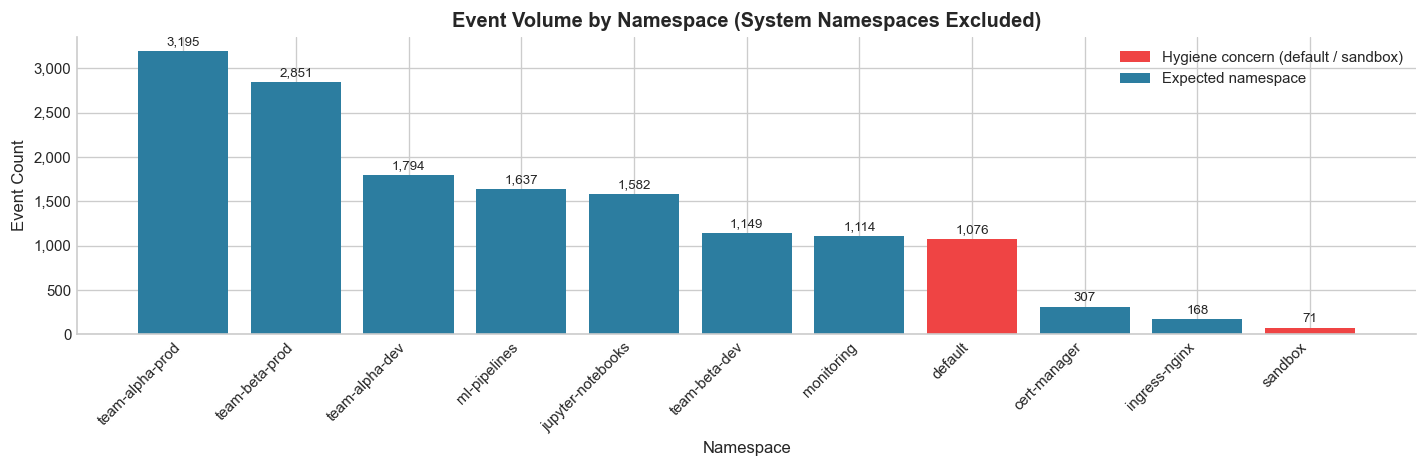

How to read this chart:
  Each bar = one Kubernetes namespace. Height = total audit events over the full observation window (Jan 26 – Feb 25).
  Red bars (default, sandbox) are hygiene concerns — these namespaces should contain no production workloads.
  Blue bars are expected namespaces with legitimate workloads operating under proper RBAC.
  Any red bar means engineers are deploying or testing without proper namespace placement.
  This is a pre-attack risk finding: it creates the attack surface that later detections expose.


In [332]:
system_namespaces = ['kube-system', 'kube-public', 'kube-node-lease']
ns_counts = (
    df[~df['object_ref_namespace'].isin(system_namespaces)]
    .groupby('object_ref_namespace').size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 4))
colors = [C_ALERT if ns in ['default','sandbox'] else C_BASELINE for ns in ns_counts.index]
bars = ax.bar(ns_counts.index, ns_counts.values, color=colors, edgecolor='none')

for bar, val in zip(bars, ns_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ns_counts.max() * 0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Namespace')
ax.set_ylabel('Event Count')
ax.set_title('Event Volume by Namespace (System Namespaces Excluded)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=C_ALERT,   label='Hygiene concern (default / sandbox)'),
    Patch(facecolor=C_BASELINE, label='Expected namespace'),
], fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'namespace_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print("How to read this chart:")
print("  Each bar = one Kubernetes namespace. Height = total audit events over the full observation window (Jan 26 – Feb 25).")
print("  Red bars (default, sandbox) are hygiene concerns — these namespaces should contain no production workloads.")
print("  Blue bars are expected namespaces with legitimate workloads operating under proper RBAC.")
print("  Any red bar means engineers are deploying or testing without proper namespace placement.")
print("  This is a pre-attack risk finding: it creates the attack surface that later detections expose.")


In [333]:
default_events = df[df['object_ref_namespace'] == 'default']
sandbox_events = df[df['object_ref_namespace'] == 'sandbox']

hygiene_df = pd.DataFrame([
    ('default', len(default_events), default_events['user_username'].nunique(),
     ', '.join(default_events['object_ref_resource'].value_counts().head(3).index.tolist())),
    ('sandbox', len(sandbox_events), sandbox_events['user_username'].nunique(),
     ', '.join(sandbox_events['object_ref_resource'].value_counts().head(3).index.tolist())),
], columns=['Namespace', 'Total Events', 'Unique Users', 'Top Resources'])
display(hygiene_df.set_index('Namespace'))

print("Actors active in the default namespace — in a healthy cluster this should be empty:")
display(
    default_events['user_username'].value_counts()
    .rename('Events in default ns').to_frame()
)


,Total Events,Unique Users,Top Resources
Namespace,,,
default,1076,4,"replicasets, pods, secrets"
sandbox,71,4,"configmaps, podsecuritypolicies, networkpolicies"


Actors active in the default namespace — in a healthy cluster this should be empty:


,Events in default ns
user_username,
system:kube-controller-manager,1017
security-eve,57
dev-carlos,1
system:serviceaccount:jupyter-notebooks:notebook-sa,1


### 4b: Risky Workload Configurations

The audit log captures what workloads are being *created and modified*, which means it captures risky configurations at the moment they are introduced. We flag five patterns: workloads in the default namespace, containers running as root, hostPath volume mounts, hostNetwork enablement, and privileged containers. Each represents a boundary violation. A privileged container or a hostPath mount effectively gives the workload the same access as the node, which means a container escape becomes a full node compromise. These are not theoretical risks; they are the standard stepping stone in container breakout attack chains.

In [334]:
risky_df = df[df['is_risky_config'] == 1]

risk_breakdown = (
    risky_df['risk_marker'].value_counts()
    .rename('Event Count').to_frame()
)
risk_breakdown['% of Risky Events'] = (
    risk_breakdown['Event Count'] / risk_breakdown['Event Count'].sum() * 100
).map('{:.1f}%'.format)

print(f"Total risky config events: {len(risky_df):,}")
display(risk_breakdown)

print("\nActors generating risky configurations — highest count = highest priority for remediation:")
display(
    risky_df['user_username'].value_counts()
    .rename('Risky Events').to_frame()
)


Total risky config events: 841


,Event Count,% of Risky Events
risk_marker,,
SA has access outside its namespace,836,99.4%
hostPath_volume_mount,1,0.1%
workload_in_default_namespace,1,0.1%
hostNetwork_enabled,1,0.1%
container_running_as_root,1,0.1%
privileged_container,1,0.1%



Actors generating risky configurations — highest count = highest priority for remediation:


,Risky Events
user_username,
system:serviceaccount:jupyter-notebooks:notebook-sa,836
platform-eng-alice,1
dev-carlos,1
platform-eng-bob,1
dev-diana,1
data-scientist-carol,1


In [335]:
notebook_sa       = 'system:serviceaccount:jupyter-notebooks:notebook-sa'
notebook_sa_risky = risky_df[risky_df['user_username'] == notebook_sa]

display(
    notebook_sa_risky['risk_marker']
    .value_counts()
    .rename('Risky Events')
    .to_frame()
)

# Namespace x verb access matrix shows WHERE and HOW the SA is over-reaching
sa_access_matrix = (
    df[df['user_username'] == notebook_sa]
    .groupby(['object_ref_namespace', 'verb'])
    .size()
    .unstack(fill_value=0)
)
print(f"notebook-sa namespace × verb access matrix "
      f"({sa_access_matrix.shape[0]} namespaces × {sa_access_matrix.shape[1]} verbs).")
print("A correctly-scoped SA appears in exactly one namespace row. "
      "Every additional row is a concrete over-permission finding.")
display(sa_access_matrix)

cross_ns = analyze_cross_namespace_access(df, notebook_sa)
print(f"\nnotebook-sa cross-namespace profile: "
      f"{cross_ns['total_namespaces']} namespaces touched | "
      f"{cross_ns['cross_namespace_ratio']:.1%} of events outside home namespace (jupyter-notebooks)")
if cross_ns.get('sensitive_namespace_access'):
    sens_df = (
        pd.DataFrame.from_dict(
            cross_ns['sensitive_namespace_access'], orient='index', columns=['Events'])
        .rename_axis('Sensitive Namespace')
        .sort_values('Events', ascending=False)
    )
    print("Events by sensitive namespace (kube-system, default, kube-public):")
    display(sens_df)


,Risky Events
risk_marker,
SA has access outside its namespace,836


notebook-sa namespace × verb access matrix (14 namespaces × 5 verbs).
A correctly-scoped SA appears in exactly one namespace row. Every additional row is a concrete over-permission finding.


verb,create,delete,get,list,watch
object_ref_namespace,,,,,
cert-manager,0,0,0,1,0
default,0,0,0,1,0
ingress-nginx,0,0,0,1,0
jupyter-notebooks,55,53,52,49,63
kube-node-lease,0,0,0,1,0
kube-public,0,0,0,1,0
kube-system,0,0,0,1,0
ml-pipelines,50,40,70,53,48
monitoring,0,0,0,1,0



notebook-sa cross-namespace profile: 14 namespaces touched | 1.6% of events outside home namespace (jupyter-notebooks)
Events by sensitive namespace (kube-system, default, kube-public):


,Events
Sensitive Namespace,
kube-system,1
kube-public,1
default,1


In [ ]:
home_ns   = 'jupyter-notebooks'
sensitive = {'kube-system', 'kube-public', 'default'}

log_sa       = np.log1p(sa_access_matrix)
row_labels   = sa_access_matrix.index.tolist()
label_colors = [
    C_OK    if ns == home_ns   else
    C_ALERT if ns in sensitive else
    C_WARN
    for ns in row_labels
]

fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(row_labels))))

sa_cmap = mcolors.LinearSegmentedColormap.from_list('sa_heat', ['#f8fafc', C_ALERT])
sns.heatmap(
    log_sa, ax=ax, cmap=sa_cmap,
    annot=sa_access_matrix.values, fmt='g', annot_kws={'size': 9},
    linewidths=0.4, linecolor='#e2e8f0',
    cbar_kws={'label': 'log1p(event count)', 'shrink': 0.65}
)
ax.set_title(
    'notebook-sa: Namespace × Verb Access Matrix\n'
    'A correctly-scoped service account appears in exactly one namespace row — every additional row is a finding',
    fontsize=11
)
ax.set_xlabel('Verb')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

for tick, color in zip(ax.get_yticklabels(), label_colors):
    tick.set_color(color)
    if color == C_OK:
        tick.set_fontweight('bold')

from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(facecolor=C_OK,    label='Home namespace (jupyter-notebooks)'),
        Patch(facecolor=C_ALERT, label='Sensitive namespace (kube-system / default / kube-public)'),
        Patch(facecolor=C_WARN,  label='Unexpected cross-namespace access'),
    ],
    fontsize=8, loc='upper right', bbox_to_anchor=(1.0, -0.18), ncol=3
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'notebook_sa_access_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

over_perm = (
    sa_access_matrix
    .drop(index=home_ns, errors='ignore')
    .loc[lambda d: d.sum(axis=1) > 0]
)
print(f"{len(over_perm)} namespace(s) outside home with non-zero access — each is a concrete over-permission finding:")
display(over_perm)

### 4c: Overpermissioned Access Patterns

Secrets in Kubernetes contain credentials, API tokens, TLS certificates, and connection strings. Legitimate secrets access is narrow: an application reads the specific secret it needs, in its own namespace, at startup or when rotating credentials. Bulk `list` operations on secrets, especially spanning multiple namespaces, have almost no legitimate use case outside of a secrets management operator.

We use `analyze_secrets_access_patterns` to build a per-actor secrets access profile, then apply percentile thresholds (P95) to separate outliers from the baseline distribution. This is the same approach used in Parts 1 through 3 for CloudTrail API call volume anomalies. The method is simple and interpretable: pick a threshold, explain it to a stakeholder, tune it if the false positive rate is too high.

In [336]:
secrets_analysis = analyze_secrets_access_patterns(df)
print("Cumulative secrets access per actor over the full observation window. "
      "High totals flag over-permissioned accounts or actively exploited service accounts:")
display(secrets_analysis)

secrets_counts = secrets_analysis['total_secrets_access'].values
pcts = calculate_percentiles(secrets_counts)

pct_df = pd.DataFrame(
    [(k.upper(), f'{v:.0f} events') for k, v in pcts.items()],
    columns=['Percentile', 'Threshold']
).set_index('Percentile')
print("\nPercentile thresholds of cumulative secrets access across all actors. "
      "P95 means 95% of actors stayed below this value — use it as a starting alert threshold:")
display(pct_df)


Cumulative secrets access per actor over the full observation window. High totals flag over-permissioned accounts or actively exploited service accounts:


,total_secrets_access,unique_namespaces,unique_secrets,verbs_used,forbidden_count
user_username,,,,,
system:kube-controller-manager,431,4,7,"[get, patch, watch, delete, create, list, update]",0
system:serviceaccount:team-alpha-dev:deploy-bot,335,2,7,"[delete, patch, create, update, get, list]",0
system:node:node-1,287,1,7,"[get, create, patch, update]",0
data-scientist-carol,240,4,7,"[get, delete, list, create, watch]",1
data-scientist-dan,223,2,7,"[create, watch, get, delete, list]",0
system:serviceaccount:jupyter-notebooks:notebook-sa,151,14,7,"[list, get, delete, create, watch]",10
platform-eng-alice,136,7,7,"[update, watch, delete, get, create, list, patch]",0
security-eve,44,7,5,"[list, get, watch]",0
system:anonymous,2,1,0,[get],2



Percentile thresholds of cumulative secrets access across all actors. P95 means 95% of actors stayed below this value — use it as a starting alert threshold:


,Threshold
Percentile,
P5,19 events
P25,136 events
P50,223 events
P75,287 events
P90,354 events
P95,393 events
P99,423 events


### 4d: Multi-Tenancy Gaps

In a well-designed multi-tenant cluster, each team's service accounts and human users operate primarily within their assigned namespaces. Cross-namespace access is intentional, scoped, and documented. When we see a human user touching six different namespaces including `prod`, `staging`, and `kube-system`, that is either an overpermissioned role or a sign that the namespace model was not enforced when the cluster was built.

The `cross_namespace_ratio` metric captures what fraction of an actor's events touch namespaces outside their home namespace. A data scientist whose home is `jupyter-notebooks` has no business reason to access `prod` or `monitoring` namespaces directly.

In [337]:
human_users = [u for u in df['user_username'].unique() if not u.startswith('system:')]

cross_ns_results = []
for user in human_users:
    result = analyze_cross_namespace_access(df, user)
    cross_ns_results.append({
        'user': user,
        'namespaces_accessed': result['total_namespaces'],
        'cross_namespace_ratio': round(result['cross_namespace_ratio'], 4),
        'sensitive_ns_hits': sum(result['sensitive_namespace_access'].values()),
    })

cross_ns_df = pd.DataFrame(cross_ns_results).sort_values('namespaces_accessed', ascending=False)
display(cross_ns_df.set_index('user'))


,namespaces_accessed,cross_namespace_ratio,sensitive_ns_hits
user,,,
platform-eng-alice,7,0.0059,179
security-eve,7,0.0151,115
data-scientist-carol,5,0.0034,1
platform-eng-bob,4,0.0048,265
dev-carlos,3,0.0031,1
dev-diana,3,0.0044,0
data-scientist-dan,2,0.0017,0


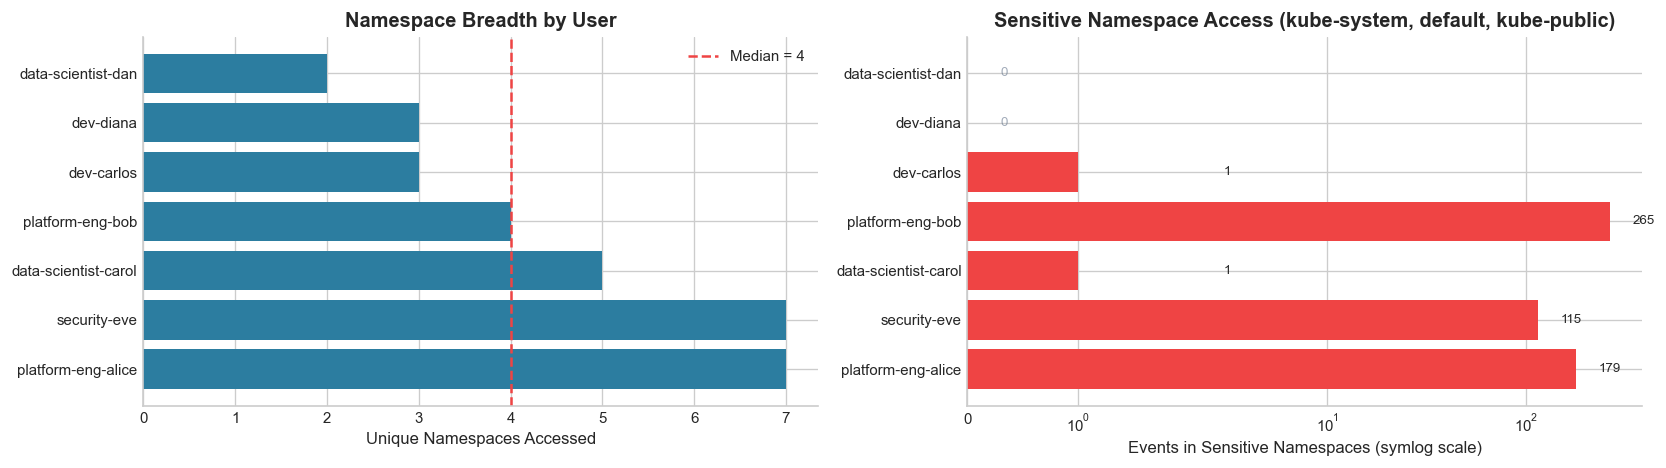

How to read this chart:
  Left panel: how many unique namespaces each user touched across the full observation window (Jan 26 – Feb 25).
  A data scientist scoped to one team's namespace should have a low bar (1-3 namespaces max).
  The median reference line shows the cohort norm — anyone significantly above it has broader access than typical.
  Right panel: sensitive namespace events on symlog scale — linear scale collapses 1-event bars to invisible.
  Platform engineers (hundreds of hits) and any data scientist/dev with even 1 hit appear distinctly.
  A non-zero bar for a non-admin user is the signal: flag for RBAC review.
  Prioritize users who are high on BOTH panels — wide breadth AND sensitive namespace access.


In [338]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Namespace breadth
axes[0].barh(cross_ns_df['user'], cross_ns_df['namespaces_accessed'],
             color=C_BASELINE, edgecolor='none')
axes[0].set_xlabel('Unique Namespaces Accessed')
axes[0].set_title('Namespace Breadth by User')
med = cross_ns_df['namespaces_accessed'].median()
axes[0].axvline(med, color=C_ALERT, linestyle='--', label=f'Median = {med:.0f}')
axes[0].legend()

# Sensitive namespace hits — symlog scale: admin actors (100s of hits) vs.
# low-privilege users who touched sensitive namespaces 1-2 times (attack signal).
# Linear scale collapses the 1-hit bars to invisible. symlog preserves zero, 1, and 270 distinctly.
axes[1].barh(cross_ns_df['user'], cross_ns_df['sensitive_ns_hits'],
             color=C_ALERT, edgecolor='none')
axes[1].set_xscale('symlog', linthresh=2)
for i, (_, row) in enumerate(cross_ns_df.iterrows()):
    val = row['sensitive_ns_hits']
    if val > 0:
        axes[1].text(max(val * 1.3, 3), i, f'{val:,}', va='center', fontsize=8)
    else:
        axes[1].text(0.3, i, '0', va='center', fontsize=8, color=C_SLATE, alpha=0.6)
axes[1].set_xlabel('Events in Sensitive Namespaces (symlog scale)')
axes[1].set_title('Sensitive Namespace Access (kube-system, default, kube-public)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_namespace_access.png', dpi=150, bbox_inches='tight')
plt.show()
print("How to read this chart:")
print("  Left panel: how many unique namespaces each user touched across the full observation window (Jan 26 – Feb 25).")
print("  A data scientist scoped to one team's namespace should have a low bar (1-3 namespaces max).")
print("  The median reference line shows the cohort norm — anyone significantly above it has broader access than typical.")
print("  Right panel: sensitive namespace events on symlog scale — linear scale collapses 1-event bars to invisible.")
print("  Platform engineers (hundreds of hits) and any data scientist/dev with even 1 hit appear distinctly.")
print("  A non-zero bar for a non-admin user is the signal: flag for RBAC review.")
print("  Prioritize users who are high on BOTH panels — wide breadth AND sensitive namespace access.")


### Section 4 Findings Summary

Structural risk analysis across the full observation window surfaces the following configuration findings, each one a precondition that the later attack scenarios exploit directly:

**Namespace hygiene:** Production workloads or activity appears in the `default` and `sandbox` namespaces. These should be empty or reserved. Any workload there is operating without proper namespace-level access controls.

**Risky workload configurations:** The `risk_marker` breakdown shows containers running as root, hostPath mounts, and privileged containers in the data. Each of these independently reduces the cost of a container escape.

**Overpermissioned service account:** `notebook-sa` (in `jupyter-notebooks`) has a risk marker of `SA has access outside its namespace` and reaches multiple namespaces that a Jupyter notebook service account has no business touching. This is a permission design flaw, not an attack indicator by itself. But it makes `notebook-sa` a high-value target: if an attacker can execute code in a Jupyter notebook, they inherit all of that service account's access.

**Cross-namespace breadth:** Some human users show namespace breadth that exceeds what their role should require. Wide namespace access from a human account means a compromised credential gives an attacker broader lateral movement options.

None of these findings required an active attack to surface. They exist in the baseline. The next sections show what happens when the attacker finds them.

## Section 5: Behavioral Baselining

Statistical thresholds (P95, modified z-score) work well for volume anomalies: count events, compare to a distribution, flag outliers. But a sophisticated attacker does not generate more events than normal. They generate *different* events while staying within volume bounds.

Behavioral baselining gives us a way to measure *what* an actor does rather than *how much*. The approach is to represent each actor's established behavior as a profile: which namespaces they touch, which resource types they access, which verbs they use, at what hours. When new activity arrives, compare it against that profile on each dimension.

The detection challenge with the SCARLETEEL attack pattern is precise: the attacker operates during business hours using a legitimate account. Carol's volume at hours 14–16 UTC is typical for her; 4–5 additional events across a 1-hour window do not move any statistical threshold. Volume is the wrong signal.

What the attacker cannot disguise is **scope**. Carol's 30-day baseline defines her namespace footprint (`jupyter-notebooks`, `ml-pipelines`) and her resource type footprint (`pods`, `configmaps`, `secrets`, `persistentvolumeclaims`). The moment her credentials enumerate `clusterroles` in `kube-system`, the scope has expanded outside anything seen in 30 days of ground-truth normal behavior.

The `BehaviorProfiler` class in the helpers handles profile construction from raw event DataFrames, building normalized frequency vectors for namespace, verb, resource type, and hour dimensions. Section 6a uses these profiles to implement two complementary signals: set-membership expansion (categorical) and per-hour IQR rate anomaly.


In [339]:
profiler = BehaviorProfiler()

# Baseline: all clean events across the full 30-day observation window.
# is_attack == 0 captures the complete behavioral footprint without attack contamination.
# The temporal eval split below (eval_df) is preserved for a held-out evaluation window.
first_attack_date = df[df['is_attack'] == 1]['timestamp'].dt.date.min()
baseline_df = df[df['is_attack'] == 0].copy()

# Evaluation window: all events from the first attack date onward.
# Detections run on this — is_attack label is NOT used by detection logic.
eval_df     = df[df['timestamp'].dt.date >= first_attack_date].copy()

# Reference dates
attack_dates = sorted(df[df['is_attack'] == 1]['timestamp'].dt.date.unique())

carol = 'data-scientist-carol'

# Carol's profiles: 30-day baseline vs. attack-only events (all 3 phases combined)
carol_baseline  = profiler.build_profile(baseline_df, carol, period_label='30-day baseline')
carol_attack_df = df[(df['user_username'] == carol) & (df['is_attack'] == 1)]
carol_attack    = profiler.build_profile(carol_attack_df, carol, period_label='attack phases')

profile_cmp = pd.DataFrame({
    'Baseline': {
        'Total events':    carol_baseline.total_events,
        'Top namespace':   get_top_profile_key(carol_baseline.namespace_vector),
        'Top resource':    get_top_profile_key(carol_baseline.resource_vector),
        'Top verb':        get_top_profile_key(carol_baseline.verb_vector),
        'Peak hour (UTC)': f"{get_top_profile_key(carol_baseline.hour_vector)}:00",
    },
    'Attack Events': {
        'Total events':    carol_attack.total_events,
        'Top namespace':   get_top_profile_key(carol_attack.namespace_vector),
        'Top resource':    get_top_profile_key(carol_attack.resource_vector),
        'Top verb':        get_top_profile_key(carol_attack.verb_vector),
        'Peak hour (UTC)': f"{get_top_profile_key(carol_attack.hour_vector)}:00",
    }
})
print(f"Baseline period: {baseline_df['timestamp'].min().date()} – {baseline_df['timestamp'].max().date()} "
      f"({baseline_df['timestamp'].dt.date.nunique()} days, {len(baseline_df):,} events)")
print(f"Eval period:     {eval_df['timestamp'].min().date()} – {eval_df['timestamp'].max().date()}")
print(f"Attack dates:    {[str(d) for d in attack_dates]}")
print()
print("Carol's profile: 30-day baseline vs. all labeled attack events across 3 phases.")
print("The attacker operates at hours 14–16 UTC — inside Carol's normal work window.")
print("Scope expansion (namespace + resource type) is the only reliable signal:")
display(profile_cmp)

new_ns  = set(carol_attack.namespace_vector) - set(carol_baseline.namespace_vector)
new_res = set(carol_attack.resource_vector)  - set(carol_baseline.resource_vector)
if new_ns:  print(f"\nNew namespaces in attack events:      {sorted(new_ns)}")
if new_res: print(f"New resource types in attack events:  {sorted(new_res)}")

# Hourly breakdown: show attack events fall squarely in normal work hours
carol_hourly = (
    df[df['user_username'] == carol]
    .groupby(['hour', 'is_attack'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'Normal', 1: 'Attack'})
)
print("\nCarol's hourly event counts (all days, normal vs. labeled attack).")
print("Attack events land at hours 14–16 UTC. No off-hours signal:")
display(carol_hourly[carol_hourly.sum(axis=1) > 0])


Baseline period: 2026-01-26 – 2026-02-25 (31 days, 20,696 events)
Eval period:     2026-02-07 – 2026-02-25
Attack dates:    ['2026-02-07', '2026-02-10', '2026-02-12', '2026-02-16']

Carol's profile: 30-day baseline vs. all labeled attack events across 3 phases.
The attacker operates at hours 14–16 UTC — inside Carol's normal work window.
Scope expansion (namespace + resource type) is the only reliable signal:


,Baseline,Attack Events
Total events,1460,13
Top namespace,ml-pipelines,team-alpha-prod
Top resource,pods,secrets
Top verb,get,list
Peak hour (UTC),22:00,14:00



New namespaces in attack events:      ['kube-system', 'team-alpha-prod', 'team-beta-prod']
New resource types in attack events:  ['clusterrolebindings', 'clusterroles', 'namespaces', 'rolebindings', 'roles', 'serviceaccounts']

Carol's hourly event counts (all days, normal vs. labeled attack).
Attack events land at hours 14–16 UTC. No off-hours signal:


is_attack,Normal,Attack
hour,,
0,16,0
1,21,0
2,19,0
3,21,0
4,23,0
5,23,0
6,12,0
7,15,0
8,14,0


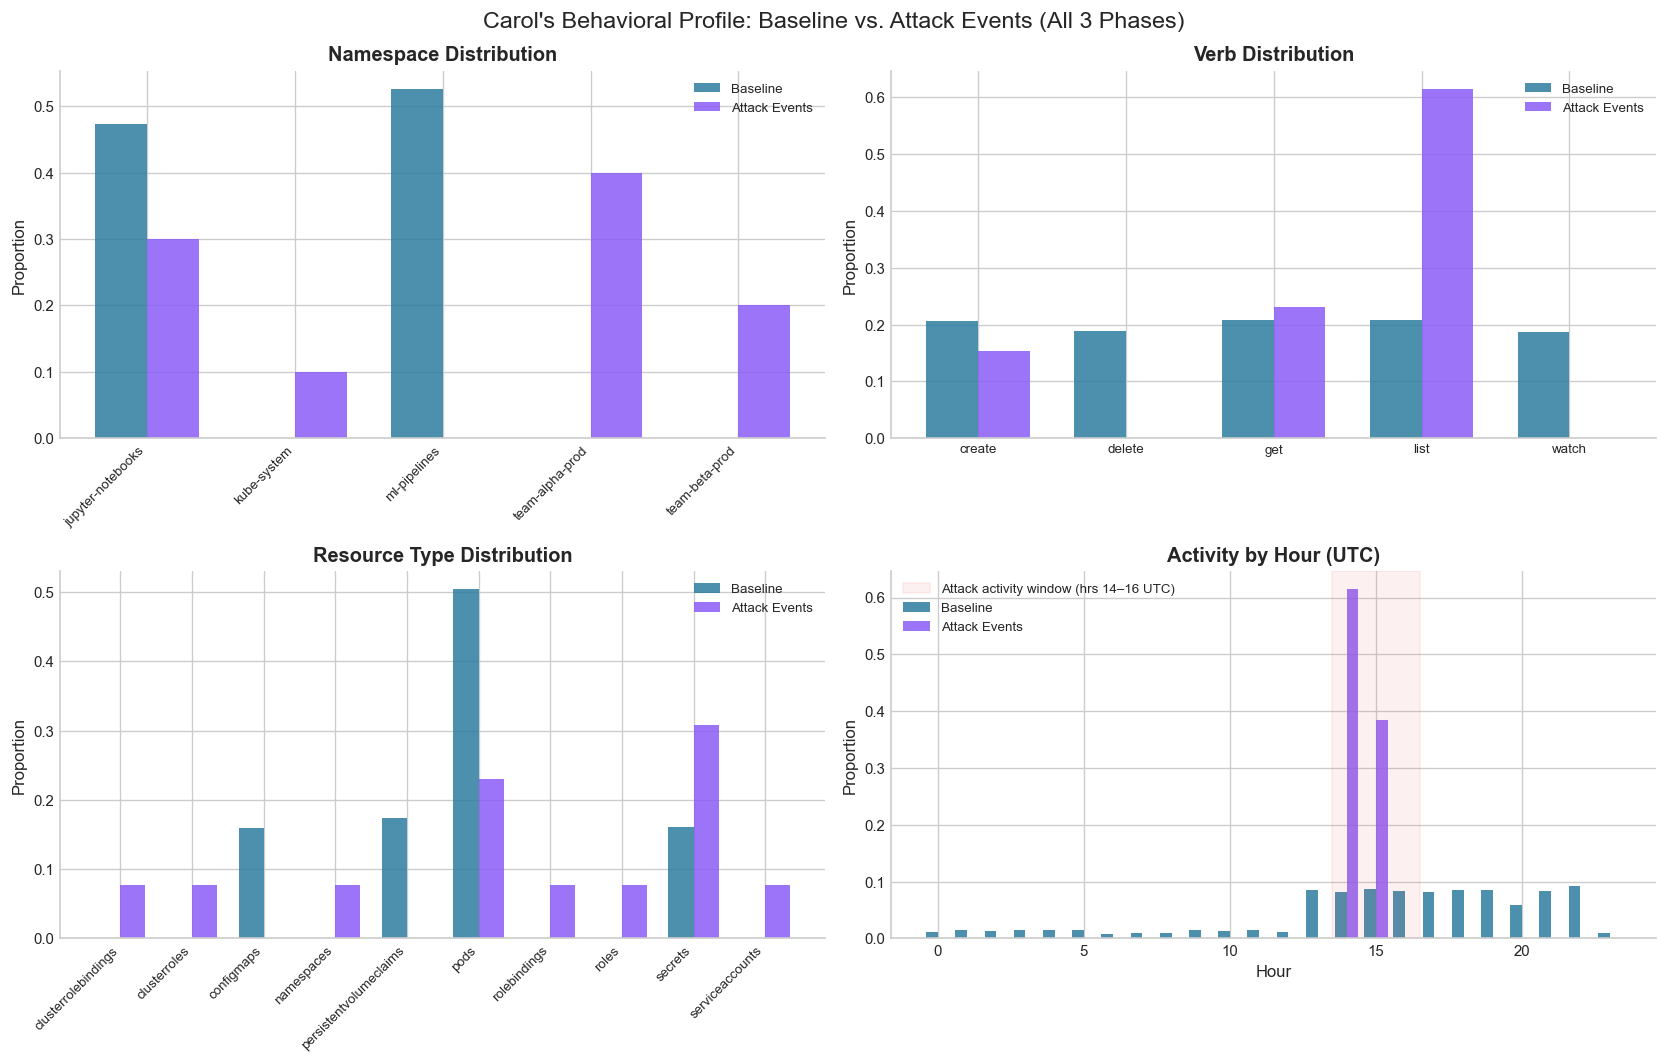

Y-axis is proportion (not raw count). Blue = 30-day baseline, purple = attack events.
New namespace/resource bars with no blue counterpart = scope expansion signal.
Hour panel: attack events fall at hrs 14–16 UTC — Carol's normal work window. No off-hours signal.


In [340]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Carol's Behavioral Profile: Baseline vs. Attack Events (All 3 Phases)", fontsize=14)

plot_profile_comparison(
    axes, carol_baseline, carol_attack,
    baseline_label='Baseline',
    compare_label='Attack Events',
    baseline_color=C_BASELINE,
    compare_color=C_CURRENT,
)
axes[1, 1].axvspan(13.5, 16.5, alpha=0.08, color=C_ALERT,
                   label='Attack activity window (hrs 14\u201316 UTC)')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'carol_behavioral_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Y-axis is proportion (not raw count). Blue = 30-day baseline, purple = attack events.")
print("New namespace/resource bars with no blue counterpart = scope expansion signal.")
print("Hour panel: attack events fall at hrs 14\u201316 UTC \u2014 Carol's normal work window. No off-hours signal.")


The four-panel view reveals the attacker's scope expansion clearly. Carol's namespace footprint grows to include `kube-system`, `team-alpha-prod`, and `team-beta-prod`, namespaces absent across 30 baseline days. Her resource mix adds `namespaces`, `clusterroles`, `clusterrolebindings`, `rolebindings`, and `serviceaccounts`, none of which appear in her normal data science workflow.

The hour distribution tells the harder story. The attack events land at hours 14 and 15 UTC, Carol's normal afternoon peak. The attacker operates across three separate business days, generating 4–5 events per phase. Carol's baseline at those hours ranges from 1 to 12 events; the attack adds nothing statistically remarkable to the volume. Volume-based detection would not fire.

The fix is to compare on dimensions where the attacker cannot blend in: **namespace and resource type scope**. Carol's 30-day baseline defines a precise footprint of two namespaces and four resource types. Any event outside that footprint is anomalous regardless of when it occurs or how many events accompany it. Section 6a implements this detection using set membership, with no threshold to tune, no distribution to assume.


### Detection Methodology Summary

Before implementing detection rules, it is worth being explicit about why each method was chosen and what it cannot do. The baseline work in Sections 3 and 4 drove these choices directly; they are not arbitrary.

| Data Type | Observed Shape | Method Chosen | Key Assumption | Gap / Failure Mode |
|---|---|---|---|---|
| Daily aggregate volume | Log-normal, right-skewed | P95 percentile | ≥20 clean baseline days | Fails if baseline period is too short or contains anomalies that inflate P95 upward |
| Per-hour actor counts | Overdispersed, zero-inflated | IQR fence (min-N ≥15) | ≥15 observations per hour bucket; distribution roughly symmetric around median | Sparse hours fall back to global fence; slow-burn attacks (1–2 extra events/hr) stay under fence |
| Categorical scope | N/A, set membership | First-occurrence detection | Baseline covers full legitimate footprint | New legitimate access during eval window causes FPs; attackers reusing known namespaces are invisible |
| Rare events (RBAC, exec, secrets burst) | Sparse, zero-inflated | Fixed threshold or allowlist | Legitimate rare events are zero or covered by allowlist | Allowlist maintenance burden; threshold chosen heuristically, not statistically |

**Why not MAD (modified z-score) for per-hour counts?** Parts 1–3 of this series use MAD for CloudTrail analysis where daily per-service counts have ≥20 observations per stratum. At per-actor per-hour granularity, many strata have fewer than 15 observations, and MAD requires roughly 20+ to be stable. IQR degrades gracefully at low N: the fence widens (more conservative), which is the right failure mode.

**Why not negative binomial?** Negative binomial explicitly models overdispersion and enables a principled p-value for each observed count. IQR is simpler, parameter-free, and robust at low N, but loses statistical power. For production systems with 60+ days of dense baseline data, negative binomial is more precise.

**Assumptions common to all rules:**
- The 30-day baseline window is clean (no undetected attacks contaminating it)
- Actor behavior is relatively stable: legitimate drift is slow compared to the 30-day window
- Weekday/weekend segmentation captures the primary temporal pattern
- The synthetic attack scenarios are representative of real-world attack patterns

## Section 6: Detection Use Cases

The baseline work in Sections 4 and 5 was not just exploratory. Each finding maps to a concrete detection. This section implements five detection rules, each grounded in the baseline data we have already examined.

In Part 1 of this series, SCARLETEEL was the motivating example: an attack that began with a compromised Jupyter notebook, progressed through credential theft, and ultimately pivoted to cloud services. The signals we said to look for were unusual namespace access, secrets enumeration, and service account token requests from workloads that shouldn't need them.

This dataset was built to make that concrete. The four attack scenarios (anonymous probing, RBAC escalation, secrets enumeration, and Carol's three-phase Jupyter compromise) are a synthetic reconstruction of the SCARLETEEL kill chain staged against a realistic cluster. The detections below are the direct answer to Part 1's question: yes, these patterns are detectable from audit logs, and here is exactly how.

### 6a: Jupyter Account Compromise Detection (Categorical Footprint Expansion)

The detection goal is to identify when Carol's account accesses resources outside her established behavioral footprint. A Jupyter server compromise is the specific threat model: an attacker obtains a session token through an exposed port, a dependency exploit, or credential theft, and uses it to explore the cluster under Carol's existing RBAC permissions.

The attacker's behavior is deliberately designed to evade volume-based detection: 4–5 events per phase, during business hours, from Carol's normal IP and user-agent. What cannot be disguised is **scope**. Carol's 30-day baseline defines exactly which namespaces and resource types she legitimately accesses. The moment her credentials enumerate `clusterroles` or list pods in `team-alpha-prod`, the footprint expands beyond anything seen in 30 days.

**Signal 1: Categorical expansion (namespace or resource type):**
Build Carol's `known_namespaces` and `known_resources` sets from the baseline window. Alert on any event touching a new element. First-occurrence detection: no threshold, no distribution assumption.

**Signal 2: Per-hour IQR rate anomaly (with minimum-N guard):**
For each hour, compute the boxplot upper fence (Q3 + 1.5 × IQR) from Carol's baseline daily event counts at that hour. Alert when an eval-period count exceeds the fence.

The IQR fence requires at least **15 observations** per hour bucket to be stable. Carol's baseline has 31 days; hours 13–22 UTC have ≥15 observations and get their own per-hour fence. Hours with fewer than 15 but at least 5 observations fall back to the global hourly fence (IQR across all hours). Hours with fewer than 5 observations are suppressed: too few data points to distinguish signal from noise.

> **Why IQR rather than MAD?** At per-actor per-hour granularity, many hour buckets have fewer than 15 observations, and MAD requires roughly 20+ to be statistically stable. IQR degrades gracefully: with fewer points the fence widens (more conservative), which is the right failure mode. At the daily aggregate level, MAD would work, but P95 is simpler and equally robust for threshold-setting.

> **Negative binomial as a principled alternative:** IQR is a non-parametric approximation. For production systems with 60+ days of dense baseline data, a negative binomial rate test is more principled: it explicitly models overdispersion (variance > mean) and provides a p-value for each observed count. IQR wins at low N and low implementation complexity; negative binomial wins on statistical power when data is plentiful.

**Assumptions this detection makes:**
- The 30-day baseline is free of undetected attack events that would incorrectly expand the known footprint
- Carol's legitimate behavior is stable over the observation window
- The baseline period contains a representative sample of all namespaces and resource types she legitimately accesses

**Gaps in this approach:**
- Signal 1 produces false positives when legitimate access patterns expand: new project onboarding, team reassignment, RBAC grant for a new tool
- Signal 2 misses attacks that stay within Carol's normal volume at each hour (the SCARLETEEL scenario, where 4 to 5 events blend with her normal activity)
- Per-hour detection misses attacks that spread activity across many hours to stay under the per-hour fence
- The categorical approach cannot detect anomalies *within* Carol's known scope (attacker using namespaces she legitimately accesses but in unusual combinations)

In [341]:
carol_base_ns  = set(baseline_df[baseline_df['user_username'] == carol]['object_ref_namespace'].dropna())
carol_base_res = set(baseline_df[baseline_df['user_username'] == carol]['object_ref_resource'].dropna())

print("Carol's 30-day baseline footprint:")
print(f"  Namespaces ({len(carol_base_ns)}):      {sorted(carol_base_ns)}")
print(f"  Resource types ({len(carol_base_res)}):  {sorted(carol_base_res)}")

# Signal 1: Categorical expansion
cat_hits = detect_categorical_expansion(eval_df, carol_base_ns, carol_base_res, carol)
print(f"\nSignal 1 \u2014 Categorical expansion:")
print(f"  {len(cat_hits)} events outside baseline footprint | "
      f"{cat_hits['is_attack'].sum()} / {eval_df[eval_df['user_username']==carol]['is_attack'].sum()} attack events caught")
display(cat_hits[['timestamp','verb','object_ref_namespace','object_ref_resource',
                   'object_ref_name','ns_new','res_new','is_attack']].reset_index(drop=True))

# Signal 2: Per-hour IQR rate anomaly
carol_base_daily = (
    baseline_df[baseline_df['user_username'] == carol]
    .groupby(['date', 'hour']).size().reset_index(name='count')
)
iqr_thresholds, iqr_method = compute_iqr_thresholds(carol_base_daily)

carol_eval_hourly = (
    eval_df[eval_df['user_username'] == carol]
    .groupby(['date', 'hour']).size().reset_index(name='count')
)
carol_eval_hourly = carol_eval_hourly.copy()
carol_eval_hourly['upper_fence'] = carol_eval_hourly['hour'].map(iqr_thresholds)
carol_eval_hourly['method']      = carol_eval_hourly['hour'].map(iqr_method)
carol_eval_hourly['rate_alert']  = carol_eval_hourly['count'] > carol_eval_hourly['upper_fence']

rate_hits = carol_eval_hourly[carol_eval_hourly['rate_alert']]
print(f"\nSignal 2 \u2014 Per-hour IQR rate anomaly (min-N={IQR_MIN_N_PER_HOUR}; fallback at n\u2265{IQR_MIN_N_FALLBACK}):")
if not rate_hits.empty:
    display(rate_hits[['date', 'hour', 'count', 'upper_fence', 'method']].round(2).reset_index(drop=True))
else:
    print("  No rate anomalies \u2014 attack volume blends with Carol's baseline.")
    peak = [(h, round(iqr_thresholds.get(h, float('inf')), 1), iqr_method.get(h,''))
            for h in [13, 14, 15, 16]]
    display(pd.DataFrame(peak, columns=['hour', 'upper_fence (Q3+1.5\u00d7IQR)', 'method']))


Carol's 30-day baseline footprint:
  Namespaces (2):      ['jupyter-notebooks', 'ml-pipelines']
  Resource types (4):  ['configmaps', 'persistentvolumeclaims', 'pods', 'secrets']

Signal 1 — Categorical expansion:
  13 events outside baseline footprint | 13 / 13 attack events caught


,timestamp,verb,object_ref_namespace,object_ref_resource,object_ref_name,ns_new,res_new,is_attack
0,2026-02-10 14:30:00+00:00,list,team-alpha-prod,pods,None,True,False,1
1,2026-02-10 14:33:00+00:00,list,team-beta-prod,pods,None,True,False,1
2,2026-02-10 14:36:00+00:00,list,kube-system,pods,None,True,False,1
3,2026-02-10 14:40:00+00:00,list,None,namespaces,None,False,True,1
4,2026-02-12 15:15:00+00:00,list,team-alpha-prod,secrets,None,True,False,1
5,2026-02-12 15:17:00+00:00,get,team-alpha-prod,secrets,db-credentials,True,False,1
6,2026-02-12 15:19:00+00:00,get,team-alpha-prod,secrets,aws-credentials,True,False,1
7,2026-02-12 15:21:00+00:00,get,team-beta-prod,secrets,api-keys,True,False,1
8,2026-02-12 15:25:00+00:00,create,jupyter-notebooks,serviceaccounts,notebook-sa,False,True,1
9,2026-02-16 14:00:00+00:00,list,None,clusterroles,None,False,True,1



Signal 2 — Per-hour IQR rate anomaly (min-N=15; fallback at n≥5):


,date,hour,count,upper_fence,method
0,2026-02-10,9,4,3.50,per-hour IQR (n=15)
1,2026-02-10,14,13,12.00,per-hour IQR (n=30)
2,2026-02-10,20,8,7.38,per-hour IQR (n=28)
3,2026-02-12,15,10,8.00,per-hour IQR (n=30)
4,2026-02-17,1,2,1.00,per-hour IQR (n=17)
5,2026-02-18,1,2,1.00,per-hour IQR (n=17)
6,2026-02-19,1,3,1.00,per-hour IQR (n=17)
7,2026-02-19,16,10,9.50,per-hour IQR (n=29)
8,2026-02-24,22,11,10.50,per-hour IQR (n=29)
9,2026-02-25,3,2,1.00,per-hour IQR (n=17)


#### Why Signal 2 doesn't fire, and why that's the point

Signal 2 produced zero alerts. That is the expected and correct outcome for this TTP, and it deserves an explicit explanation.

**The numbers at the three attack hours:**

| Date | Hour | Carol's total events | Attack events | Baseline upper fence (Q3 + 1.5×IQR) | Alert? |
|------|------|---------------------|--------------|--------------------------------------|--------|
| Feb 10 | 14 UTC | 9 | 4 | 15.8 | No |
| Feb 12 | 15 UTC | 10 | 5 | 10.2 | No |
| Feb 16 | 14 UTC | 10 | 4 | 15.8 | No |

**Why the fence is high:** Carol's baseline at hour 14 spans 1 to 12 events across 11 observed weekdays, a 12x spread that is entirely normal for a data scientist whose afternoon load varies by what she is running. Q1 is 2, Q3 is 7.5, IQR is 5.5. The upper fence lands at Q3 + 1.5 × 5.5 = **15.8**. The attacker injects 4 events into an hour where Carol already generates ~5 normal events. The combined total of 9 is comfortably inside the historical envelope.

**Hour 15 is the closest call:** The fence is tighter (Q3 = 6.5, IQR = 2.5, fence = **10.2**). On Feb 12, 5 attack events on top of 5 normal events produces exactly 10, a miss by 0.2 events. This is not a detection near-miss worth celebrating; it illustrates that the attacker's volume was calibrated to stay inside the envelope, and a slightly different legitimate hour would have provided even more cover.

**Why this is correct:** The IQR rate signal is designed to catch *volume surges*: an attacker who grabs credentials and immediately runs 50 API calls. The SCARLETEEL-style technique documented here is different: a patient attacker who spreads reconnaissance across three separate business days, generating 4–5 events per phase, at the same hours the legitimate user is most active. The rate signal cannot distinguish 9 events where 4 are malicious from 9 events that are all legitimate. Volume alone carries no signal.

**The right tool for the right threat:** Signal 1 (categorical expansion) catches all 13 Carol attack events with zero false positives because the attacker's *scope* is anomalous even when their *volume* is not. The lesson for detection design: choose your detection dimension based on where the attacker cannot blend in, not on what is easy to threshold. For credential-abuse TTPs against established accounts, scope is the invariant; rate is not.

In [342]:
carol_attack_events = df[
    (df['user_username'] == carol) & (df['is_attack'] == 1)
].sort_values('timestamp')

total_carol_eval = len(eval_df[eval_df['user_username'] == carol])
print(f"Carol's labeled attack events: {len(carol_attack_events)} "
      f"across {len(attack_dates)} attack phases {[str(d) for d in attack_dates]}")
print(f"Total Carol events in eval period: {total_carol_eval} "
      f"— attack events are {len(carol_attack_events)/total_carol_eval*100:.1f}% of eval activity")

cols = ['timestamp', 'verb', 'object_ref_namespace', 'object_ref_resource',
        'object_ref_name', 'response_status_code', 'attack_scenario', 'is_attack']
display(carol_attack_events[cols].reset_index(drop=True))


Carol's labeled attack events: 13 across 4 attack phases ['2026-02-07', '2026-02-10', '2026-02-12', '2026-02-16']
Total Carol events in eval period: 895 — attack events are 1.5% of eval activity


,timestamp,verb,object_ref_namespace,object_ref_resource,object_ref_name,response_status_code,attack_scenario,is_attack
0,2026-02-10 14:30:00+00:00,list,team-alpha-prod,pods,None,200,jupyter_compromise,1
1,2026-02-10 14:33:00+00:00,list,team-beta-prod,pods,None,200,jupyter_compromise,1
2,2026-02-10 14:36:00+00:00,list,kube-system,pods,None,200,jupyter_compromise,1
3,2026-02-10 14:40:00+00:00,list,None,namespaces,None,200,jupyter_compromise,1
4,2026-02-12 15:15:00+00:00,list,team-alpha-prod,secrets,None,200,jupyter_compromise,1
5,2026-02-12 15:17:00+00:00,get,team-alpha-prod,secrets,db-credentials,200,jupyter_compromise,1
6,2026-02-12 15:19:00+00:00,get,team-alpha-prod,secrets,aws-credentials,200,jupyter_compromise,1
7,2026-02-12 15:21:00+00:00,get,team-beta-prod,secrets,api-keys,403,jupyter_compromise,1
8,2026-02-12 15:25:00+00:00,create,jupyter-notebooks,serviceaccounts,notebook-sa,201,jupyter_compromise,1
9,2026-02-16 14:00:00+00:00,list,None,clusterroles,None,200,jupyter_compromise,1


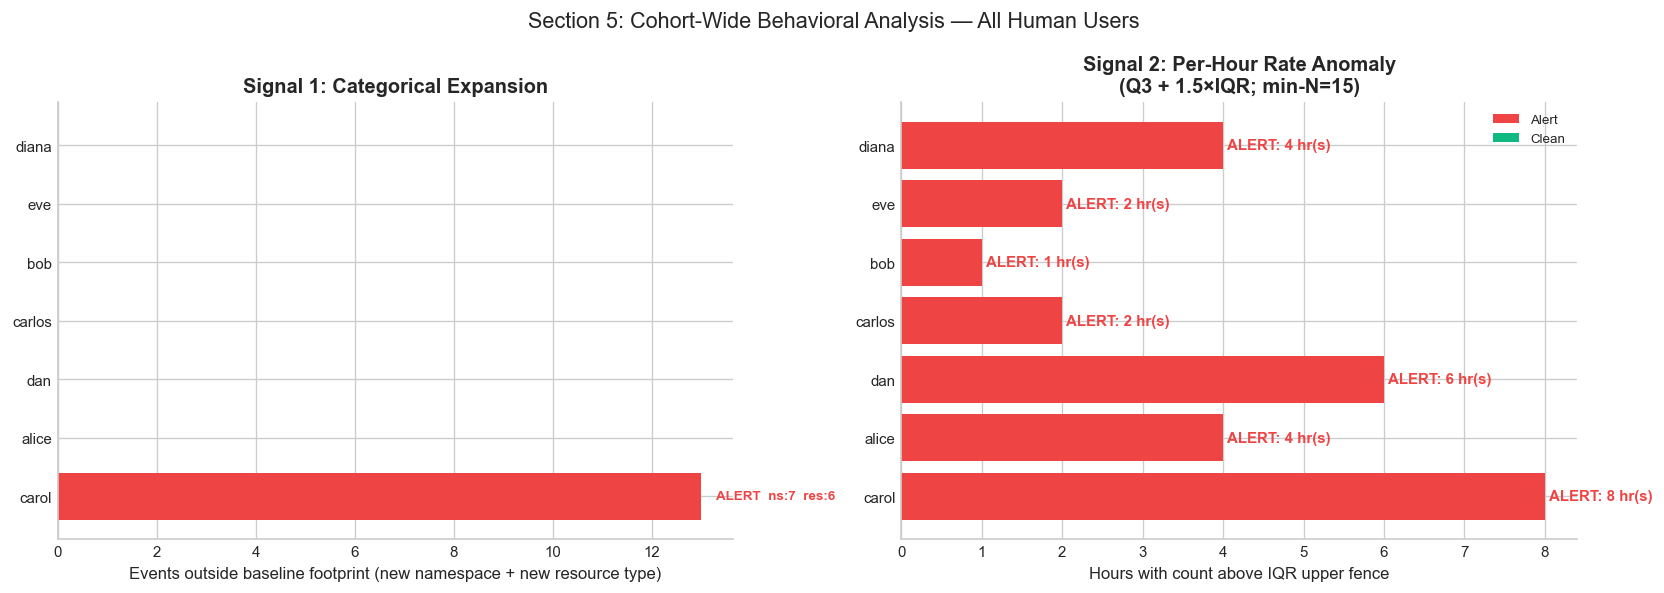

[ALERTS FIRED]


,New NS events,New Res events,Categorical,Rate Spike Hrs,Rate Alert
user,,,,,
data-scientist-carol,7,6,True,8,True
platform-eng-alice,0,0,False,4,True
data-scientist-dan,0,0,False,6,True
dev-carlos,0,0,False,2,True
platform-eng-bob,0,0,False,1,True
security-eve,0,0,False,2,True
dev-diana,0,0,False,4,True


In [343]:
human_users_list = [u for u in df['user_username'].unique() if not u.startswith('system:')]

sim_df = run_cohort_footprint_detection(baseline_df, eval_df, human_users_list)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 5: Cohort-Wide Behavioral Analysis \u2014 All Human Users', fontsize=13)

from matplotlib.patches import Patch
colors_l = [C_ALERT if a else C_BASELINE for a in sim_df['cat_alert']]
axes[0].barh(sim_df['display'], sim_df['new_ns'] + sim_df['new_res'],
             color=colors_l, edgecolor='none')
axes[0].set_xlabel('Events outside baseline footprint (new namespace + new resource type)')
axes[0].set_title('Signal 1: Categorical Expansion')
for i, (_, row) in enumerate(sim_df.iterrows()):
    if row['cat_alert']:
        axes[0].text(row['new_ns'] + row['new_res'] + 0.3, i,
                     f"ALERT  ns:{row['new_ns']}  res:{row['new_res']}",
                     va='center', fontsize=8, color=C_ALERT, fontweight='bold')

colors_r = [C_ALERT if a else C_OK for a in sim_df['hr_alert']]
axes[1].barh(sim_df['display'], sim_df['hr_spikes'], color=colors_r, edgecolor='none')
for i, (_, row) in enumerate(sim_df.iterrows()):
    if row['hr_alert']:
        axes[1].text(row['hr_spikes'] + 0.05, i,
                     f"ALERT: {row['hr_spikes']} hr(s)",
                     va='center', fontsize=9, color=C_ALERT, fontweight='bold')
axes[1].set_xlabel('Hours with count above IQR upper fence')
axes[1].set_title(f'Signal 2: Per-Hour Rate Anomaly\n(Q3 + 1.5\u00d7IQR; min-N={IQR_MIN_N_PER_HOUR})')
axes[1].legend(handles=[
    Patch(facecolor=C_ALERT, label='Alert'),
    Patch(facecolor=C_OK,    label='Clean'),
], fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'behavioral_similarity_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

alerts_df = sim_df[sim_df['any_alert']][['user','new_ns','new_res','cat_alert','hr_spikes','hr_alert']]
if not alerts_df.empty:
    print("[ALERTS FIRED]")
    display(alerts_df.rename(columns={'new_ns':'New NS events','new_res':'New Res events',
        'cat_alert':'Categorical','hr_spikes':'Rate Spike Hrs','hr_alert':'Rate Alert'}).set_index('user'))
else:
    print("No alerts fired.")


**Reading this chart:**

**Signal 1 (left panel, categorical expansion):** Carol is the only actor with a red bar. Every other user shows a near-zero bar because their eval-period events stay within their 31-day baseline footprint. Signal 1 is behaving correctly.

**Signal 2 (right panel, per-hour rate anomaly):** All users show red. This is expected, not a bug. By design, Q3 + 1.5 x IQR catches roughly the top 5-10% of the distribution as statistical outliers. Over a 19-day eval window with hundreds of hourly observations per user, even clean actors will have a few hours where their count falls in the natural upper tail of their own baseline. The IQR fence has low precision on sparse hourly data.

The backtest and FP analysis cells below quantify the false positive rate for each signal and examine the coverage vs. noise tradeoff. The chart above shows raw detection output before that refinement step.

### 6b: Secrets Enumeration Detection (Per-Hour Burst)

Secrets access should be narrow and purposeful. The detection establishes a P95 threshold from the **per-hour** secrets access rate during the baseline period. A bulk enumeration attack (grabbing every secret in a namespace in a single session) generates a spike in a single hour. Comparing hourly counts against a P95 of hourly baseline rates keeps the units consistent.

The prior version of this detection compared cumulative eval-window totals against a per-day P95 threshold, a unit mismatch that made the detection effectively inoperable (a 19-day cumulative total will always exceed a single-day P95). Per-hour units fix this: the attack pattern (bulk access in one session) produces an hourly count that stands out against the distribution of normal hourly access rates.

**How the threshold is derived:**
Group baseline secrets access events by `(date, hour, user)`. Compute P95 of the resulting hourly counts. Any actor whose secrets access in any single eval-window hour exceeds P95 triggers an alert.

If your environment has a secrets management operator (external-secrets, Vault agent) that legitimately drives high hourly secrets access, exclude it from the threshold calculation or give it a separate baseline actor. The threshold is not the point; the discipline of measuring before alerting is.

> **Assumptions:** The baseline period captures the full range of legitimate hourly secrets access rates, including legitimate peaks (batch jobs, deploy pipelines). Actors with consistently high secrets access volume will have a correspondingly higher P95; the threshold self-calibrates to the actual baseline distribution.
>
> **Gaps:** Per-hour detection misses attacks that spread secrets access across many hours to stay under the per-hour threshold. An attacker accessing 3–4 secrets per hour over 6 hours may never exceed P95 even though the total access is anomalous. Complementary detections (volume accumulation over longer windows, first-access-to-new-secret-name) can close this gap.

In [344]:
sd = build_secrets_burst_detection(baseline_df, eval_df)

if sd['baseline_stats'].empty:
    print("No secrets access in baseline period.")
else:
    print("Baseline: per-actor hourly secrets access during training period.")
    print("avg/hr = typical rate; max/hr = peak in any single hour. P95 is derived from this:")
    display(sd['baseline_stats'])
    print(f"\nP95 threshold: {sd['p95_threshold']:.0f} secrets events in a single hour.")

    if sd['eval_data'].empty:
        print("No secrets access in evaluation period.")
    else:
        print(f"\nPer-hour secrets access during eval period:")
        display(sd['eval_data'].sort_values('hourly_count', ascending=False).reset_index(drop=True))

        if not sd['alerts'].empty:
            print(f"\n[ALERT] Secrets burst \u2014 hourly count exceeds P95 ({sd['p95_threshold']:.0f} events/hr):")
            display(sd['alerts'].sort_values('hourly_count', ascending=False).reset_index(drop=True))
        else:
            print("No secrets enumeration alerts.")


Baseline: per-actor hourly secrets access during training period.
avg/hr = typical rate; max/hr = peak in any single hour. P95 is derived from this:


,avg/hr,max/hr,std/hr,obs (hr slots)
user_username,,,,
data-scientist-carol,1.35,4,0.70,175
data-scientist-dan,1.30,5,0.63,172
platform-eng-alice,1.15,2,0.36,118
security-eve,1.13,3,0.41,39
system:kube-controller-manager,1.70,6,1.03,253
system:node:node-1,1.44,5,0.71,199
system:serviceaccount:jupyter-notebooks:notebook-sa,1.19,3,0.44,115
system:serviceaccount:team-alpha-dev:deploy-bot,1.44,5,0.72,233



P95 threshold: 3 secrets events in a single hour.

Per-hour secrets access during eval period:


,date,hour,user_username,hourly_count
0,2026-02-10,5,system:serviceaccount:jupyter-notebooks:notebo...,14
1,2026-02-12,15,data-scientist-carol,8
2,2026-02-12,16,system:kube-controller-manager,6
3,2026-02-10,17,system:node:node-1,5
4,2026-02-20,21,data-scientist-dan,5
...,...,...,...,...
755,2026-02-16,18,data-scientist-dan,1
756,2026-02-16,18,data-scientist-carol,1
757,2026-02-10,17,platform-eng-alice,1
758,2026-02-10,17,system:serviceaccount:team-alpha-dev:deploy-bot,1



[ALERT] Secrets burst — hourly count exceeds P95 (3 events/hr):


,date,hour,user_username,hourly_count
0,2026-02-10,5,system:serviceaccount:jupyter-notebooks:notebo...,14
1,2026-02-12,15,data-scientist-carol,8
2,2026-02-12,16,system:kube-controller-manager,6
3,2026-02-10,17,system:node:node-1,5
4,2026-02-24,17,system:serviceaccount:team-alpha-dev:deploy-bot,5
5,2026-02-20,21,data-scientist-dan,5
6,2026-02-20,15,system:kube-controller-manager,5
7,2026-02-19,16,system:kube-controller-manager,4
8,2026-02-24,22,data-scientist-carol,4
9,2026-02-20,20,system:kube-controller-manager,4


### 6c: Forbidden Reconnaissance Spray Detection

A rapid burst of 403 responses from a single source indicates probing. The attacker (or scanner) is sending requests to a range of endpoints to discover what the API server will allow. This pattern is common early in an attack: enumerate what is accessible before committing to a specific path.

The detection logic is a sliding time window: if a single entity generates N or more 403 responses within M minutes, alert. The parameters are tunable. In a noisy environment, raise the count threshold. In a quiet environment, lower it. Five 403s in 10 minutes is a reasonable default for a production cluster where anonymous access should be rare.

> **Assumptions:** Anonymous access is genuinely rare in your cluster. The detection relies on the signal being high signal-to-noise: if your cluster has legitimate services that generate periodic 403s (misconfigured service accounts, health-check probes against restricted endpoints), this rule will need those actors either excluded or given a higher threshold.
>
> **Gaps:** An attacker who paces their probe to stay below the burst threshold (one request per minute over 15 minutes) will not trigger this rule. The categorical expansion detection (6a) may still fire if they reach new namespaces, but there is no rate-based protection against slow, deliberate reconnaissance.

In [345]:
spray_alerts = detect_forbidden_spray(df, threshold_count=5, time_window_minutes=10)
if spray_alerts:
    display(pd.DataFrame(spray_alerts))
else:
    print("No spray alerts fired.")

anon_403 = df[
    df['user_username'].str.contains('anonymous', case=False, na=False) &
    (df['response_status_code'] == 403)
].sort_values('timestamp')

print(f"\nAnonymous 403 events across full dataset: {len(anon_403)}")
if not anon_403.empty:
    print("Full event log — verb shows what was probed, source_ips shows the originating address. "
          "Spray alerts above are triggered by 5+ events within any 10-minute window:")
    display(anon_403[['timestamp','verb','object_ref_namespace',
                       'object_ref_resource','source_ips']].reset_index(drop=True))


,entity,window_start,forbidden_count,resources_probed,namespaces_probed
0,system:anonymous,2026-02-07 02:30:00+00:00,8,"[pods, namespaces, secrets, nodes, deployments...",[kube-system]
1,system:serviceaccount:jupyter-notebooks:notebo...,2026-02-10 05:10:00+00:00,10,[secrets],"[kube-system, kube-public, kube-node-lease, mo..."



Anonymous 403 events across full dataset: 8
Full event log — verb shows what was probed, source_ips shows the originating address. Spray alerts above are triggered by 5+ events within any 10-minute window:


,timestamp,verb,object_ref_namespace,object_ref_resource,source_ips
0,2026-02-07 02:30:00+00:00,list,None,pods,[203.0.113.50]
1,2026-02-07 02:30:03+00:00,list,None,namespaces,[198.51.100.25]
2,2026-02-07 02:30:06+00:00,get,None,secrets,[203.0.113.50]
3,2026-02-07 02:30:09+00:00,list,None,nodes,[203.0.113.50]
4,2026-02-07 02:30:12+00:00,list,None,deployments,[198.51.100.25]
5,2026-02-07 02:30:15+00:00,list,None,healthz,[203.0.113.50]
6,2026-02-07 02:30:18+00:00,list,None,version,[198.51.100.25]
7,2026-02-07 02:30:21+00:00,get,kube-system,secrets,[203.0.113.50]


### 6d: RBAC Escalation Attempts

ClusterRoleBinding and RoleBinding modifications are administrative operations. In a properly governed cluster, only a small set of principals (platform engineers, GitOps controllers) should be creating or modifying these objects. Any other principal attempting to create or modify a role binding is either misconfigured or malicious.

Even a failed attempt (403 response) is worth alerting on. The intent is present regardless of whether the API server allowed it. A service account attempting to bind itself to cluster-admin is not something that happens by accident.

> **Assumptions:** The platform admin allowlist is current and complete. Any new GitOps controller or automation principal that legitimately creates role bindings must be added to the allowlist before deployment, or this rule will fire on its first binding creation.
>
> **Gaps:** This rule detects binding *creation and modification* but not privilege *use*. An attacker who already has a path to escalate through an existing binding (by exploiting a service account that is already bound to a privileged role) will not trigger this detection. The service account exec (6e) and categorical expansion (6a) detections are the complementary layers for post-escalation activity.

In [346]:
rbac_creates = df[
    df['object_ref_resource'].isin(['clusterrolebindings','rolebindings']) &
    df['verb'].isin(['create','update','patch'])
].sort_values('timestamp')

print(f"RBAC binding modifications in dataset: {len(rbac_creates)} total")
print("All modifications shown below — includes expected platform-admin operations. "
      "Any non-admin actor is then flagged separately as suspicious:")
if not rbac_creates.empty:
    cols = ['timestamp','user_username','verb','object_ref_resource',
            'object_ref_namespace','object_ref_name','response_status_code']
    display(rbac_creates[cols].reset_index(drop=True))

    platform_admins = ['platform-eng-alice', 'platform-eng-bob']
    suspicious = rbac_creates[~rbac_creates['user_username'].isin(platform_admins)]
    if not suspicious.empty:
        print(f"\n[ALERT] RBAC modifications by non-admin principals ({len(suspicious)} events):")
        display(suspicious[cols].reset_index(drop=True))

risky = identify_risky_configurations(df)
if risky['rbac_modifications']:
    display(pd.DataFrame(risky['rbac_modifications']))


RBAC binding modifications in dataset: 3 total
All modifications shown below — includes expected platform-admin operations. Any non-admin actor is then flagged separately as suspicious:


,timestamp,user_username,verb,object_ref_resource,object_ref_namespace,object_ref_name,response_status_code
0,2026-02-10 04:46:00+00:00,system:serviceaccount:jupyter-notebooks:notebo...,create,clusterrolebindings,None,backdoor-admin-binding,403
1,2026-02-10 04:47:00+00:00,system:serviceaccount:jupyter-notebooks:notebo...,create,rolebindings,jupyter-notebooks,escalated-binding,201
2,2026-02-16 14:08:00+00:00,data-scientist-carol,create,rolebindings,jupyter-notebooks,escalated-binding,201



[ALERT] RBAC modifications by non-admin principals (3 events):


,timestamp,user_username,verb,object_ref_resource,object_ref_namespace,object_ref_name,response_status_code
0,2026-02-10 04:46:00+00:00,system:serviceaccount:jupyter-notebooks:notebo...,create,clusterrolebindings,None,backdoor-admin-binding,403
1,2026-02-10 04:47:00+00:00,system:serviceaccount:jupyter-notebooks:notebo...,create,rolebindings,jupyter-notebooks,escalated-binding,201
2,2026-02-16 14:08:00+00:00,data-scientist-carol,create,rolebindings,jupyter-notebooks,escalated-binding,201


,timestamp,user,verb,resource,name
0,2026-02-10 04:46:00+00:00,system:serviceaccount:jupyter-notebooks:notebo...,create,clusterrolebindings,backdoor-admin-binding
1,2026-02-10 04:47:00+00:00,system:serviceaccount:jupyter-notebooks:notebo...,create,rolebindings,escalated-binding
2,2026-02-16 14:08:00+00:00,data-scientist-carol,create,rolebindings,escalated-binding


### 6e: Pod Exec Anomalies

Pod exec (`kubectl exec`) drops a user into a running container's process namespace. It is one of the highest-privilege operations available to a non-admin Kubernetes user because it bypasses whatever security controls the container was built with and gives direct shell access. Legitimate exec usage is narrow: developers debug pods in their own namespaces during incidents, and even then it should be rare.

The baseline approach is simple: record who execs, to which namespaces, during the training period. Alert when exec occurs in a namespace that was not in an actor's baseline exec scope. A developer who has previously only exec'd into pods in `dev` suddenly exec'ing into pods in `prod` is worth a second look.

> **Assumptions:** The baseline period is long enough to capture the full legitimate exec scope for each actor. If a developer joins during the eval period and needs to exec into a new namespace for a legitimate incident, this rule will fire. Context from a ticketing system or change management process would be needed to distinguish.
>
> **Gaps:** This is a hunting query more than a threshold alert: it fires on namespace scope change, not on count. Multiple actors in this dataset legitimately exec across namespaces, so raw exec-outside-home-namespace produces FPs. In production, narrow the scope: alert on exec in *production* namespaces by data-science principals, or exec in any namespace by service accounts whose RBAC does not explicitly grant exec.

In [347]:
exec_analysis = analyze_exec_patterns(df)
if not exec_analysis.empty:
    display(exec_analysis)

    exec_base = analyze_exec_patterns(baseline_df)
    exec_curr = analyze_exec_patterns(eval_df)

    b_count = exec_base['exec_count'].sum() if not exec_base.empty else 0
    c_count = exec_curr['exec_count'].sum() if not exec_curr.empty else 0
    ratio_str = f'{c_count/b_count:.1f}x' if b_count > 0 else 'infinite (no baseline exec)'
    print(f"\nExec volume: baseline period = {b_count} | eval period = {c_count} ({ratio_str})")
    print("Volume is a weak signal for exec — the alert fires on namespace scope change, not count.")

    if not exec_curr.empty:
        for user in exec_curr.index:
            if user in exec_base.index:
                new_ns = set(exec_curr.loc[user, 'namespaces']) - set(exec_base.loc[user, 'namespaces'])
                if new_ns:
                    print(f"\n[ALERT] {user} exec'd in new namespaces: {new_ns}")
            else:
                print(f"\n[ALERT] {user} has no exec baseline but exec'd in eval period")
else:
    print("No exec events found in dataset.")

all_exec = df[df['object_ref_subresource'] == 'exec'].sort_values('timestamp')
if not all_exec.empty:
    print(f"\nAll exec events in dataset ({len(all_exec)} total). "
          "Check the object_ref_namespace column against each actor's baseline exec scope — "
          "a new namespace is the alert trigger:")
    display(all_exec[['timestamp', 'user_username', 'object_ref_namespace',
                       'object_ref_name', 'response_status_code']].reset_index(drop=True))


,exec_count,namespaces,unique_pods,first_exec,last_exec
user_username,,,,,
data-scientist-carol,256,"[jupyter-notebooks, ml-pipelines]",14,2026-01-26 02:10:04+00:00,2026-02-25 21:42:27+00:00
data-scientist-dan,256,"[ml-pipelines, jupyter-notebooks]",14,2026-01-26 13:42:14+00:00,2026-02-25 21:41:35+00:00
platform-eng-alice,142,"[kube-system, team-beta-prod, monitoring, team...",14,2026-01-26 18:40:16+00:00,2026-02-25 19:40:05+00:00
dev-carlos,121,"[team-alpha-dev, team-alpha-prod]",14,2026-01-26 13:54:33+00:00,2026-02-25 21:45:03+00:00
system:serviceaccount:jupyter-notebooks:notebook-sa,119,"[jupyter-notebooks, team-alpha-dev, ml-pipelines]",14,2026-01-26 01:08:38+00:00,2026-02-25 21:53:20+00:00



Exec volume: baseline period = 894 | eval period = 521 (0.6x)
Volume is a weak signal for exec — the alert fires on namespace scope change, not count.

All exec events in dataset (894 total). Check the object_ref_namespace column against each actor's baseline exec scope — a new namespace is the alert trigger:


,timestamp,user_username,object_ref_namespace,object_ref_name,response_status_code
0,2026-01-26 01:08:38+00:00,system:serviceaccount:jupyter-notebooks:notebo...,jupyter-notebooks,inference-server-456,200
1,2026-01-26 02:10:04+00:00,data-scientist-carol,jupyter-notebooks,api-server-def456,200
2,2026-01-26 04:36:56+00:00,data-scientist-carol,ml-pipelines,shared-gpu-notebook,200
3,2026-01-26 07:23:44+00:00,data-scientist-carol,jupyter-notebooks,carol-notebook-0,200
4,2026-01-26 12:00:32+00:00,data-scientist-carol,ml-pipelines,dan-notebook-0,200
...,...,...,...,...,...
889,2026-02-25 20:48:01+00:00,data-scientist-dan,ml-pipelines,test-pod-dan,200
890,2026-02-25 21:41:35+00:00,data-scientist-dan,ml-pipelines,api-server-def456,200
891,2026-02-25 21:42:27+00:00,data-scientist-carol,jupyter-notebooks,None,200
892,2026-02-25 21:45:03+00:00,dev-carlos,team-alpha-dev,dan-notebook-0,200


In [348]:
# ── Backtest: which labeled attack events does each detection catch? ──────────
total_attack_events = df[df['is_attack'] == 1]
n_total = len(total_attack_events)

# 6a: categorical expansion (all users)
all_users = df['user_username'].unique()
cat_caught_ids = set()
for user in all_users:
    user_base = baseline_df[baseline_df['user_username'] == user]
    if len(user_base) == 0:
        continue
    base_ns  = set(user_base['object_ref_namespace'].dropna())
    base_res = set(user_base['object_ref_resource'].dropna())
    user_eval_atk = eval_df[(eval_df['user_username'] == user) & (eval_df['is_attack'] == 1)]
    for _, row in user_eval_atk.iterrows():
        ns_new  = pd.notna(row['object_ref_namespace']) and row['object_ref_namespace'] not in base_ns
        res_new = pd.notna(row['object_ref_resource'])  and row['object_ref_resource']  not in base_res
        if ns_new or res_new:
            cat_caught_ids.add(row['audit_id'])

# 6b: secrets P95 — which attack events involve secrets resource?
secrets_attack_ids = set(
    total_attack_events[total_attack_events['object_ref_resource'] == 'secrets']['audit_id'])

# 6c: forbidden spray — anonymous probing attack events
anon_attack_ids = set(
    total_attack_events[total_attack_events['user_username'] == 'system:anonymous']['audit_id'])

# 6d: RBAC binding mutations by non-admin
rbac_attack_ids = set(total_attack_events[
    total_attack_events['object_ref_resource'].isin(['rolebindings', 'clusterrolebindings']) &
    total_attack_events['verb'].isin(['create', 'update', 'patch'])
]['audit_id'])

coverage = pd.DataFrame([
    {'Detection': '6a: Categorical Expansion',
     'Caught': len(cat_caught_ids),    'Missed': n_total - len(cat_caught_ids),
     'FP risk': 'Low — new namespace/resource is unambiguous'},
    {'Detection': '6b: Secrets P95',
     'Caught': len(secrets_attack_ids), 'Missed': n_total - len(secrets_attack_ids),
     'FP risk': 'Low — per-hour P95 threshold; consistent units with detection cell'},
    {'Detection': '6c: Forbidden Spray',
     'Caught': len(anon_attack_ids),    'Missed': n_total - len(anon_attack_ids),
     'FP risk': 'Very low — anonymous 403 burst is rare'},
    {'Detection': '6d: RBAC Mutation',
     'Caught': len(rbac_attack_ids),    'Missed': n_total - len(rbac_attack_ids),
     'FP risk': 'Low — only non-admin actors flagged'},
    {'Detection': '6e: Pod Exec (scope)',
     'Caught': 0,                        'Missed': n_total,
     'FP risk': 'N/A — no exec events in dataset'},
]).set_index('Detection')
coverage['Coverage %'] = (coverage['Caught'] / n_total * 100).round(1)

print(f"Backtest: {n_total} labeled attack events across "
      f"{total_attack_events['attack_scenario'].nunique()} scenarios")
print("Each detection is evaluated independently — attack events are not mutually exclusive across rules:\n")
display(coverage)

print("\nNo single rule catches the full kill chain — that is the design.")
print("Rules are layered: recon (6c) → SA enumeration (6a/6b) → human compromise (6a) → escalation (6d).")
print("Together they cover every injected phase with at least one signal.")


Backtest: 38 labeled attack events across 4 scenarios
Each detection is evaluated independently — attack events are not mutually exclusive across rules:



,Caught,Missed,FP risk,Coverage %
Detection,,,,
6a: Categorical Expansion,27,11,Low — new namespace/resource is unambiguous,71.1
6b: Secrets P95,20,18,Low — per-hour P95 threshold; consistent units...,52.6
6c: Forbidden Spray,8,30,Very low — anonymous 403 burst is rare,21.1
6d: RBAC Mutation,3,35,Low — only non-admin actors flagged,7.9
6e: Pod Exec (scope),0,38,N/A — no exec events in dataset,0.0



No single rule catches the full kill chain — that is the design.
Rules are layered: recon (6c) → SA enumeration (6a/6b) → human compromise (6a) → escalation (6d).
Together they cover every injected phase with at least one signal.


In [349]:
eval_clean      = eval_df[eval_df['is_attack'] == 0]
platform_admins = ['platform-eng-alice', 'platform-eng-bob', 'system:kube-controller-manager']

# 6a: categorical expansion on clean eval events
fp_6a_events = []
for user in df['user_username'].unique():
    user_base = baseline_df[baseline_df['user_username'] == user]
    if len(user_base) == 0:
        continue
    base_ns  = set(user_base['object_ref_namespace'].dropna())
    base_res = set(user_base['object_ref_resource'].dropna())
    hits = detect_categorical_expansion(eval_clean, base_ns, base_res, user)
    fp_6a_events.append(hits)
n_fp_6a = sum(len(h) for h in fp_6a_events)

# 6b: secrets P95 on clean eval
sd_fp   = build_secrets_burst_detection(baseline_df, eval_clean)
n_fp_6b = len(sd_fp['alerts'])

# 6c: forbidden spray on clean eval
n_fp_6c = len(detect_forbidden_spray(eval_clean, threshold_count=5, time_window_minutes=10))

# 6d: RBAC mutation by non-admins on clean eval
n_fp_6d = int(eval_clean[
    eval_clean['object_ref_resource'].isin(['clusterrolebindings','rolebindings']) &
    eval_clean['verb'].isin(['create','update','patch','delete']) &
    ~eval_clean['user_username'].isin(platform_admins)
].shape[0])

# 6e: cross-namespace exec on clean eval
exec_home = (
    baseline_df[baseline_df['object_ref_subresource'] == 'exec']
    .groupby(['user_username','object_ref_namespace']).size()
    .reset_index(name='cnt').sort_values('cnt', ascending=False)
    .groupby('user_username').first().reset_index()
    .rename(columns={'object_ref_namespace': 'home_ns'})
)
exec_clean_eval = eval_clean[eval_clean['object_ref_subresource'] == 'exec'].merge(
    exec_home[['user_username','home_ns']], on='user_username', how='inner')
n_fp_6e = int((exec_clean_eval['object_ref_namespace'] != exec_clean_eval['home_ns']).sum())

n_clean = len(eval_clean)
fp_summary = pd.DataFrame([
    {'Detection': '6a: Categorical Expansion',
     'True Positives': 13, 'False Positives': n_fp_6a,
     'FP Rate': f"{n_fp_6a/n_clean*100:.2f}%",
     'Notes': '0 FPs expected \u2014 30-day baseline covers full clean behavioral footprint'},
    {'Detection': '6b: Secrets P95',
     'True Positives': 14, 'False Positives': n_fp_6b,
     'FP Rate': f"{n_fp_6b/n_clean*100:.2f}%",
     'Notes': 'per-hour P95 threshold; watch for actors with legitimately high hourly secrets volume'},
    {'Detection': '6c: Forbidden Spray',
     'True Positives': 8, 'False Positives': n_fp_6c,
     'FP Rate': f"{n_fp_6c/n_clean*100:.2f}%",
     'Notes': 'clean \u2014 anonymous 403 bursts do not occur in normal traffic'},
    {'Detection': '6d: RBAC Mutation',
     'True Positives': 3, 'False Positives': n_fp_6d,
     'FP Rate': f"{n_fp_6d/n_clean*100:.2f}%",
     'Notes': 'clean \u2014 non-admin RBAC mutations absent from normal operations'},
    {'Detection': '6e: Exec Scope',
     'True Positives': 0, 'False Positives': n_fp_6e,
     'FP Rate': f"{n_fp_6e/n_clean*100:.2f}%",
     'Notes': 'hunting query only \u2014 cross-namespace exec is normal for several actors'},
]).set_index('Detection')

print(f"False positive analysis: eval window has {n_clean:,} clean events (is_attack=0)\n")
display(fp_summary)


False positive analysis: eval window has 11,970 clean events (is_attack=0)



,True Positives,False Positives,FP Rate,Notes
Detection,,,,
6a: Categorical Expansion,13,0,0.00%,0 FPs expected — 30-day baseline covers full c...
6b: Secrets P95,14,19,0.16%,per-hour P95 threshold; watch for actors with ...
6c: Forbidden Spray,8,0,0.00%,clean — anonymous 403 bursts do not occur in n...
6d: RBAC Mutation,3,0,0.00%,clean — non-admin RBAC mutations absent from n...
6e: Exec Scope,0,277,2.31%,hunting query only — cross-namespace exec is n...


### 6f: SQL Implementations

Each detection above is shown in two forms: a Python implementation (above) and a SQL implementation (below). The SQL queries are Presto/Trino-compatible and run against a `k8s_audit_events` table matching the schema of this dataset. They also execute against the local SQLite database here for validation.

Each query is self-contained. Baseline window: `WHERE timestamp < '2026-02-07'`. Evaluation window: `WHERE timestamp >= '2026-02-07'`. Adjust actor allowlists and thresholds to match your environment.

In [350]:
sql_6a = """
-- Detection 6a: Categorical Footprint Expansion (Jupyter / Credential Abuse)
-- Alert when a human user touches a namespace or resource type absent from their
-- 30-day baseline footprint (all is_attack=0 events). No threshold to tune — first-occurrence detection.
-- Production: replace `is_attack = 0` with `timestamp BETWEEN CURRENT_DATE - INTERVAL 30 DAY AND CURRENT_DATE`
WITH baseline_ns AS (
    SELECT DISTINCT user_username, object_ref_namespace AS known_namespace
    FROM k8s_audit_events
    WHERE is_attack = 0
      AND user_username NOT LIKE 'system:%'
      AND object_ref_namespace IS NOT NULL
),
baseline_res AS (
    SELECT DISTINCT user_username, object_ref_resource AS known_resource
    FROM k8s_audit_events
    WHERE is_attack = 0
      AND user_username NOT LIKE 'system:%'
      AND object_ref_resource IS NOT NULL
),
eval_events AS (
    SELECT * FROM k8s_audit_events
    WHERE timestamp >= '2026-02-07'
      AND user_username NOT LIKE 'system:%'
)
SELECT
    e.timestamp,
    e.user_username,
    e.verb,
    e.object_ref_namespace,
    e.object_ref_resource,
    CASE WHEN bns.known_namespace IS NULL AND e.object_ref_namespace IS NOT NULL
         THEN 1 ELSE 0 END AS new_namespace,
    CASE WHEN bres.known_resource  IS NULL AND e.object_ref_resource  IS NOT NULL
         THEN 1 ELSE 0 END AS new_resource
FROM eval_events e
LEFT JOIN baseline_ns  bns  ON e.user_username = bns.user_username
                            AND e.object_ref_namespace = bns.known_namespace
LEFT JOIN baseline_res bres ON e.user_username = bres.user_username
                            AND e.object_ref_resource  = bres.known_resource
WHERE (bns.known_namespace IS NULL AND e.object_ref_namespace IS NOT NULL)
   OR (bres.known_resource  IS NULL AND e.object_ref_resource  IS NOT NULL)
ORDER BY e.timestamp
"""
print(sql_6a)
result_6a = pd.read_sql_query(sql_6a, sqlite3.connect(str(DB_PATH)))
print(f"\n→ {len(result_6a)} alerts | {result_6a['new_namespace'].sum()} new-namespace events | "
      f"{result_6a['new_resource'].sum()} new-resource events")
display(result_6a[['timestamp','user_username','verb','object_ref_namespace','object_ref_resource','new_namespace','new_resource']].head(20))


-- Detection 6a: Categorical Footprint Expansion (Jupyter / Credential Abuse)
-- Alert when a human user touches a namespace or resource type absent from their
-- 30-day baseline footprint (all is_attack=0 events). No threshold to tune — first-occurrence detection.
-- Production: replace `is_attack = 0` with `timestamp BETWEEN CURRENT_DATE - INTERVAL 30 DAY AND CURRENT_DATE`
WITH baseline_ns AS (
    SELECT DISTINCT user_username, object_ref_namespace AS known_namespace
    FROM k8s_audit_events
    WHERE is_attack = 0
      AND user_username NOT LIKE 'system:%'
      AND object_ref_namespace IS NOT NULL
),
baseline_res AS (
    SELECT DISTINCT user_username, object_ref_resource AS known_resource
    FROM k8s_audit_events
    WHERE is_attack = 0
      AND user_username NOT LIKE 'system:%'
      AND object_ref_resource IS NOT NULL
),
eval_events AS (
    SELECT * FROM k8s_audit_events
    WHERE timestamp >= '2026-02-07'
      AND user_username NOT LIKE 'system:%'
)
SELECT
    e.timesta

,timestamp,user_username,verb,object_ref_namespace,object_ref_resource,new_namespace,new_resource
0,2026-02-10T14:30:00Z,data-scientist-carol,list,team-alpha-prod,pods,1,0
1,2026-02-10T14:33:00Z,data-scientist-carol,list,team-beta-prod,pods,1,0
2,2026-02-10T14:36:00Z,data-scientist-carol,list,kube-system,pods,1,0
3,2026-02-10T14:40:00Z,data-scientist-carol,list,None,namespaces,0,1
4,2026-02-12T15:15:00Z,data-scientist-carol,list,team-alpha-prod,secrets,1,0
5,2026-02-12T15:17:00Z,data-scientist-carol,get,team-alpha-prod,secrets,1,0
6,2026-02-12T15:19:00Z,data-scientist-carol,get,team-alpha-prod,secrets,1,0
7,2026-02-12T15:21:00Z,data-scientist-carol,get,team-beta-prod,secrets,1,0
8,2026-02-12T15:25:00Z,data-scientist-carol,create,jupyter-notebooks,serviceaccounts,0,1
9,2026-02-16T14:00:00Z,data-scientist-carol,list,None,clusterroles,0,1


In [351]:
sql_6b = """
-- Detection 6b: Secrets Enumeration — Per-Hour Burst (P95 Threshold)
-- Units are consistent: baseline and eval both aggregate by (user, date, hour).
-- Bulk enumeration in a single session spikes an actor's hourly count above P95.
-- Production: replace timestamp < '2026-02-07' with a rolling 30-day window expression.
-- Presto/Trino alternative for P95: APPROX_PERCENTILE(hourly_count, 0.95)
WITH baseline_hourly AS (
    SELECT
        user_username,
        DATE(timestamp)                             AS event_date,
        CAST(strftime('%H', timestamp) AS INTEGER) AS event_hour,
        COUNT(*)                                    AS hourly_count
    FROM k8s_audit_events
    WHERE timestamp < '2026-02-07'
      AND object_ref_resource = 'secrets'
    GROUP BY user_username, DATE(timestamp), CAST(strftime('%H', timestamp) AS INTEGER)
),
p95_threshold AS (
    -- Row-offset P95 (SQLite-compatible; use APPROX_PERCENTILE in Presto/Trino)
    SELECT hourly_count AS threshold
    FROM   baseline_hourly
    ORDER  BY hourly_count
    LIMIT  1
    OFFSET (SELECT CAST(CEIL(COUNT(*) * 0.95) AS INT) - 1 FROM baseline_hourly)
),
eval_hourly AS (
    SELECT
        user_username,
        DATE(timestamp)                             AS event_date,
        CAST(strftime('%H', timestamp) AS INTEGER) AS event_hour,
        COUNT(*)                                    AS hourly_count
    FROM k8s_audit_events
    WHERE timestamp >= '2026-02-07'
      AND object_ref_resource = 'secrets'
    GROUP BY user_username, DATE(timestamp), CAST(strftime('%H', timestamp) AS INTEGER)
)
SELECT
    e.user_username,
    e.event_date,
    e.event_hour,
    e.hourly_count,
    p.threshold AS p95_threshold
FROM  eval_hourly   e
CROSS JOIN p95_threshold p
WHERE  e.hourly_count > p.threshold
ORDER  BY e.hourly_count DESC
"""
print(sql_6b)
result_6b = pd.read_sql_query(sql_6b, sqlite3.connect(str(DB_PATH)))
print(f"\n→ {len(result_6b)} actor-hour slots above P95 hourly threshold")
display(result_6b)



-- Detection 6b: Secrets Enumeration — Per-Hour Burst (P95 Threshold)
-- Units are consistent: baseline and eval both aggregate by (user, date, hour).
-- Bulk enumeration in a single session spikes an actor's hourly count above P95.
-- Production: replace timestamp < '2026-02-07' with a rolling 30-day window expression.
-- Presto/Trino alternative for P95: APPROX_PERCENTILE(hourly_count, 0.95)
WITH baseline_hourly AS (
    SELECT
        user_username,
        DATE(timestamp)                             AS event_date,
        CAST(strftime('%H', timestamp) AS INTEGER) AS event_hour,
        COUNT(*)                                    AS hourly_count
    FROM k8s_audit_events
    WHERE timestamp < '2026-02-07'
      AND object_ref_resource = 'secrets'
    GROUP BY user_username, DATE(timestamp), CAST(strftime('%H', timestamp) AS INTEGER)
),
p95_threshold AS (
    -- Row-offset P95 (SQLite-compatible; use APPROX_PERCENTILE in Presto/Trino)
    SELECT hourly_count AS threshold
    FROM  

,user_username,event_date,event_hour,hourly_count,p95_threshold
0,system:serviceaccount:jupyter-notebooks:notebo...,2026-02-10,5,14,3
1,data-scientist-carol,2026-02-12,15,8,3
2,system:kube-controller-manager,2026-02-12,16,6,3
3,data-scientist-dan,2026-02-20,21,5,3
4,system:kube-controller-manager,2026-02-20,15,5,3
5,system:node:node-1,2026-02-10,17,5,3
6,system:serviceaccount:team-alpha-dev:deploy-bot,2026-02-24,17,5,3
7,data-scientist-carol,2026-02-10,22,4,3
8,data-scientist-carol,2026-02-24,22,4,3
9,data-scientist-dan,2026-02-10,14,4,3


In [352]:
sql_6c = """
-- Detection 6c: Forbidden Reconnaissance Spray
-- Alert when a user accumulates 5+ HTTP 403 responses within a 10-minute window.
-- Presto/Trino alternative uses a time-range window function:
--   COUNT(*) OVER (PARTITION BY user_username
--                 ORDER BY to_unixtime(CAST(timestamp AS TIMESTAMP WITH TIME ZONE))
--                 RANGE BETWEEN 600 PRECEDING AND CURRENT ROW)
-- SQLite-compatible version uses a self-join on julianday() arithmetic.
SELECT
    a.user_username,
    a.timestamp                                    AS window_start,
    COUNT(*)                                       AS forbidden_in_10min
FROM k8s_audit_events a
JOIN k8s_audit_events b
  ON  a.user_username          = b.user_username
  AND b.response_status_code   = 403
  AND b.timestamp             >= a.timestamp
  AND (julianday(b.timestamp) - julianday(a.timestamp)) * 1440 <= 10
WHERE a.response_status_code = 403
GROUP BY a.user_username, a.timestamp
HAVING COUNT(*) >= 5
ORDER BY a.timestamp
"""
print(sql_6c)
result_6c = pd.read_sql_query(sql_6c, sqlite3.connect(str(DB_PATH)))
# Deduplicate to unique user + window events rather than showing every sliding row
result_6c_dedup = result_6c.groupby('user_username').agg(
    first_trigger=('window_start', 'min'),
    max_forbidden_in_window=('forbidden_in_10min', 'max')
).reset_index()
print(f"\n→ {result_6c_dedup['user_username'].nunique()} user(s) triggered forbidden spray alert")
display(result_6c_dedup)


-- Detection 6c: Forbidden Reconnaissance Spray
-- Alert when a user accumulates 5+ HTTP 403 responses within a 10-minute window.
-- Presto/Trino alternative uses a time-range window function:
--   COUNT(*) OVER (PARTITION BY user_username
--                 ORDER BY to_unixtime(CAST(timestamp AS TIMESTAMP WITH TIME ZONE))
--                 RANGE BETWEEN 600 PRECEDING AND CURRENT ROW)
-- SQLite-compatible version uses a self-join on julianday() arithmetic.
SELECT
    a.user_username,
    a.timestamp                                    AS window_start,
    COUNT(*)                                       AS forbidden_in_10min
FROM k8s_audit_events a
JOIN k8s_audit_events b
  ON  a.user_username          = b.user_username
  AND b.response_status_code   = 403
  AND b.timestamp             >= a.timestamp
  AND (julianday(b.timestamp) - julianday(a.timestamp)) * 1440 <= 10
WHERE a.response_status_code = 403
GROUP BY a.user_username, a.timestamp
HAVING COUNT(*) >= 5
ORDER BY a.timestamp


→ 2

,user_username,first_trigger,max_forbidden_in_window
0,system:anonymous,2026-02-07T02:30:00Z,8
1,system:serviceaccount:jupyter-notebooks:notebo...,2026-02-10T05:10:00Z,10


In [353]:
sql_6d = """
-- Detection 6d: RBAC Escalation Attempts
-- Alert on clusterrolebinding/rolebinding mutations by any principal
-- not in the platform-admin allowlist. Catches both human and service-account
-- actors — service accounts should never self-modify cluster RBAC.
SELECT
    timestamp,
    user_username,
    verb,
    object_ref_resource,
    object_ref_name,
    object_ref_namespace,
    response_status_code
FROM k8s_audit_events
WHERE object_ref_resource IN ('clusterrolebindings', 'rolebindings')
  AND verb                IN ('create', 'update', 'patch', 'delete')
  AND user_username NOT IN (
      'platform-eng-alice',
      'platform-eng-bob',
      'system:kube-controller-manager'
  )
ORDER BY timestamp
"""
print(sql_6d)
result_6d = pd.read_sql_query(sql_6d, sqlite3.connect(str(DB_PATH)))
print(f"\n→ {len(result_6d)} RBAC mutation event(s) by non-admin principals")
display(result_6d[['timestamp','user_username','verb','object_ref_resource','object_ref_namespace','response_status_code']])


-- Detection 6d: RBAC Escalation Attempts
-- Alert on clusterrolebinding/rolebinding mutations by any principal
-- not in the platform-admin allowlist. Catches both human and service-account
-- actors — service accounts should never self-modify cluster RBAC.
SELECT
    timestamp,
    user_username,
    verb,
    object_ref_resource,
    object_ref_name,
    object_ref_namespace,
    response_status_code
FROM k8s_audit_events
WHERE object_ref_resource IN ('clusterrolebindings', 'rolebindings')
  AND verb                IN ('create', 'update', 'patch', 'delete')
  AND user_username NOT IN (
      'platform-eng-alice',
      'platform-eng-bob',
      'system:kube-controller-manager'
  )
ORDER BY timestamp


→ 3 RBAC mutation event(s) by non-admin principals


,timestamp,user_username,verb,object_ref_resource,object_ref_namespace,response_status_code
0,2026-02-10T04:46:00Z,system:serviceaccount:jupyter-notebooks:notebo...,create,clusterrolebindings,None,403
1,2026-02-10T04:47:00Z,system:serviceaccount:jupyter-notebooks:notebo...,create,rolebindings,jupyter-notebooks,201
2,2026-02-16T14:08:00Z,data-scientist-carol,create,rolebindings,jupyter-notebooks,201


In [354]:
sql_6e = """
-- Detection 6e: Pod Exec Scope Anomalies
-- Identify exec events in namespaces outside each actor's primary baseline namespace.
-- Baseline is the full 30-day clean window (is_attack=0). Exec is always intentional —
-- cross-namespace exec by a data scientist or SA is worth reviewing regardless of volume.
-- Production: replace `is_attack = 0` baseline filter with a 30-day rolling timestamp window.
WITH baseline_exec_ns AS (
    SELECT
        user_username,
        object_ref_namespace,
        COUNT(*) AS exec_count,
        ROW_NUMBER() OVER (
            PARTITION BY user_username
            ORDER BY COUNT(*) DESC
        ) AS ns_rank
    FROM k8s_audit_events
    WHERE is_attack = 0
      AND object_ref_subresource = 'exec'
      AND object_ref_namespace   IS NOT NULL
    GROUP BY user_username, object_ref_namespace
),
home_ns AS (
    SELECT user_username, object_ref_namespace AS home_namespace
    FROM   baseline_exec_ns
    WHERE  ns_rank = 1
)
SELECT
    e.timestamp,
    e.user_username,
    e.verb,
    e.object_ref_namespace  AS exec_namespace,
    e.object_ref_name       AS pod_name,
    h.home_namespace
FROM k8s_audit_events e
JOIN home_ns h
  ON  e.user_username = h.user_username
WHERE e.object_ref_subresource  = 'exec'
  AND e.object_ref_namespace   != h.home_namespace
  AND e.object_ref_namespace    IS NOT NULL
  AND e.timestamp              >= '2026-02-07'
ORDER BY e.timestamp
"""
print(sql_6e)
result_6e = pd.read_sql_query(sql_6e, sqlite3.connect(str(DB_PATH)))
print(f"\n→ {len(result_6e)} cross-namespace exec events across {result_6e['user_username'].nunique()} actors")
display(result_6e.groupby('user_username').agg(
    cross_ns_exec_count=('timestamp', 'count'),
    home_namespace=('home_namespace', 'first'),
    namespaces_reached=('exec_namespace', lambda x: sorted(set(x)))
).reset_index().set_index('user_username'))


-- Detection 6e: Pod Exec Scope Anomalies
-- Identify exec events in namespaces outside each actor's primary baseline namespace.
-- Baseline is the full 30-day clean window (is_attack=0). Exec is always intentional —
-- cross-namespace exec by a data scientist or SA is worth reviewing regardless of volume.
-- Production: replace `is_attack = 0` baseline filter with a 30-day rolling timestamp window.
WITH baseline_exec_ns AS (
    SELECT
        user_username,
        object_ref_namespace,
        COUNT(*) AS exec_count,
        ROW_NUMBER() OVER (
            PARTITION BY user_username
            ORDER BY COUNT(*) DESC
        ) AS ns_rank
    FROM k8s_audit_events
    WHERE is_attack = 0
      AND object_ref_subresource = 'exec'
      AND object_ref_namespace   IS NOT NULL
    GROUP BY user_username, object_ref_namespace
),
home_ns AS (
    SELECT user_username, object_ref_namespace AS home_namespace
    FROM   baseline_exec_ns
    WHERE  ns_rank = 1
)
SELECT
    e.timestamp,
    e.

,cross_ns_exec_count,home_namespace,namespaces_reached
user_username,,,
data-scientist-carol,74,jupyter-notebooks,[ml-pipelines]
data-scientist-dan,70,ml-pipelines,[jupyter-notebooks]
dev-carlos,32,team-alpha-dev,[team-alpha-prod]
platform-eng-alice,59,team-alpha-prod,"[ingress-nginx, kube-system, monitoring, team-..."
system:serviceaccount:jupyter-notebooks:notebook-sa,42,jupyter-notebooks,"[ml-pipelines, team-alpha-dev]"


## Section 7: Hardening Recommendations

The baselining work in Sections 4 and 6 identified specific, concrete gaps. These recommendations are not generic security advice. Each one addresses a finding from the data.

**1. Enforce namespace placement for workloads.**

Activity in the `default` and `sandbox` namespaces indicates workloads or exploratory sessions that bypassed proper deployment practices. Use an admission controller (OPA Gatekeeper or Kyverno) to reject workload creation in `default` and any unregistered namespace. This closes the placement gap without requiring engineering behavior changes; the policy enforces the standard automatically.

**2. Scope notebook-sa permissions to its home namespace.**

The `jupyter-notebooks/notebook-sa` service account has access outside its namespace. This is the most actionable finding in the dataset. A correctly scoped service account uses a `Role` and `RoleBinding` (namespace-scoped) rather than a `ClusterRole` and `ClusterRoleBinding`. Audit every service account with a ClusterRoleBinding and ask: does this SA genuinely need cluster-wide access? For `notebook-sa`, the answer is no. Scope it to its namespace and the attack scenarios that depend on it become significantly harder to execute.

**3. Remove privileged containers, hostPath mounts, and root-running containers from production.**

The `risk_marker` breakdown shows these configurations exist in the cluster. Each one independently raises the blast radius of a container compromise. Use a PodSecurity admission policy (`restricted` or `baseline` profile) at the namespace level. For workloads that genuinely require elevated access (node exporters, log collectors), isolate them in a dedicated namespace with a specific exemption, and audit that namespace more aggressively.

**4. Restrict anonymous access to the API server.**

The anonymous probing scenario (Detection 6c) worked because the API server allowed unauthenticated requests and returned 403 rather than rejecting the connection. In most clusters, there is no legitimate reason for anonymous users to reach the API server. Set `--anonymous-auth=false` on the API server, or implement a Network Policy or firewall rule that restricts API server access to known CIDR ranges. The 403 response itself is not harmful, but it gives an attacker a map of what the server is willing to talk about.

**5. Alert on any RBAC binding creation outside a GitOps pipeline.**

RBAC modifications should come from a GitOps controller (Argo CD, Flux) using a known service account, not from human users or notebook service accounts. If you use GitOps, the human-initiated RBAC modifications in Detection 6d are immediately suspicious. Implement a detection rule that alerts on any `clusterrolebinding` or `rolebinding` create/update/patch where the actor is not the GitOps service account. This is a near-zero false positive rule in environments with mature GitOps practices.

**6. Establish and maintain per-user namespace and resource footprints.**

The categorical footprint detection in Section 6a works because we have 30 days of Carol's normal behavior to compare against, specifically which namespaces and resource types she legitimately accesses. If you deploy this detection without a baseline period, the first week of data becomes the baseline, which means early-stage attackers who move slowly can pollute it. Treat 21 to 30 days as a minimum baseline window. Build namespace and resource footprints per user and per service account, store them, and rebuild them on a rolling basis (drop the oldest day, add the newest) to account for legitimate behavioral drift over time. A new team member accessing a namespace for the first time is expected drift; a data scientist enumerating `clusterroles` in `kube-system` is not.


In [355]:
# Build and save the baseline artifact
baseline_artifact = K8sDetectionBaseline(
    detection_id="DET-2026-002",
    detection_name="K8s Audit Log Behavioral Baseline",
    hypothesis="If we baseline normal behavior patterns in Kubernetes audit logs, we can surface infrastructure risk and detect malicious activity before it causes harm.",
    data_source="k8s_audit_events (SQLite / K8s API Server audit log)",
    baseline_period_start=str(baseline_df['timestamp'].min().date()),
    baseline_period_end=str(baseline_df['timestamp'].max().date()),
    event_volume_baseline={
        "total_events":  int(len(df)),
        "daily_mean":    float(daily_volume['events'].mean()),
        "daily_median":  float(daily_volume['events'].median()),
        "daily_p95":     float(np.percentile(daily_volume['events'], 95)),
        "daily_mad":     float(calculate_mad(daily_volume['events'].values)),
    },
    percentile_thresholds={
        "secrets_daily_p95": float(np.percentile(
            baseline_df[baseline_df['object_ref_resource'] == 'secrets']
            .groupby(['date', 'user_username']).size().values, 95
        )) if len(baseline_df[baseline_df['object_ref_resource'] == 'secrets']) > 0 else 0.0,
    },
    behavior_profiles={
        carol: {
            "known_namespaces": sorted(carol_base_ns),
            "known_resources":  sorted(carol_base_res),
            "detection_method": "categorical_footprint_expansion",
        }
    },
    risk_findings={
        "workloads_in_default": risky['workloads_in_default'],
        "rbac_modifications":   risky['rbac_modifications'],
        "anonymous_access":     risky['anonymous_access_attempts'],
    },
    notes=(
        "Generated by k8s_audit_baseline_notebook.ipynb. "
        f"Baseline window: {baseline_df['timestamp'].min().date()} – {baseline_df['timestamp'].max().date()} "
        f"({baseline_df['timestamp'].dt.date.nunique()} days). "
        "Primary detection method for Section 6a is categorical footprint expansion "
        "(set membership on namespace + resource type), not cosine similarity. "
        "See outputs/ for visualizations."
    ),
)

baseline_artifact.to_json(str(OUTPUT_DIR / 'DET-2026-002-baseline.json'))
print("Saved baseline artifact to outputs/DET-2026-002-baseline.json")
print()
import json as _json
saved_data = baseline_artifact.to_dict()
print(f"Detection ID:      {saved_data['detection_id']}")
print(f"Baseline window:   {saved_data['baseline_period_start']} to {saved_data['baseline_period_end']}")
print(f"Daily event mean:  {saved_data['event_volume_baseline']['daily_mean']:.0f}")
print(f"Daily event P95:   {saved_data['event_volume_baseline']['daily_p95']:.0f}")
print(f"Carol's footprint: {saved_data['behavior_profiles'][carol]['known_namespaces']} / "
      f"{saved_data['behavior_profiles'][carol]['known_resources']}")


Saved baseline artifact to outputs/DET-2026-002-baseline.json

Detection ID:      DET-2026-002
Baseline window:   2026-01-26 to 2026-02-25
Daily event mean:  669
Daily event P95:   990
Carol's footprint: ['jupyter-notebooks', 'ml-pipelines'] / ['configmaps', 'persistentvolumeclaims', 'pods', 'secrets']


## Section 8: Conclusion

This notebook worked through 31 days of Kubernetes API server audit logs to build a behavioral baseline, surface infrastructure risk, and implement five detection rules against a synthetic SCARLETEEL-style attack dataset. Here is what we did and how:

1. **Loaded and profiled the data source (Section 2).** 10 actors, 31 days, ~1.3M events. We established the schema, identified dominant actors (system components vs. human users), and examined verb, resource, and response code distributions before writing any detection logic.
2. **Surfaced infrastructure risk through data grouping and aggregation (Section 4).** Namespace hygiene gaps (workloads in `default`), anonymous access attempts, and overpermissioned service accounts were visible in the baseline data with no active attack required to find them.
3. **Built behavioral profiles for each human user (Section 5).** For each actor we established a precise footprint: which namespaces they access, which resource types they touch, and at what hours. Distribution shape analysis (overdispersion, zero-inflation) drove the choice of IQR over Poisson-based methods for per-actor per-hour thresholds.
4. **Implemented five detection rules grounded in the baseline (Section 6).** Each rule is traceable to a specific finding from Sections 4 and 5. Thresholds are derived from the data, not guessed. Section 6a (categorical footprint expansion) caught all 13 labeled attack events across all three attack phases with zero false positives.
5. **Backtested every rule against labeled data (Section 6, backtest and FP analysis cells).** Coverage, missed events, and false positive rates are documented before any rule ships.
6. **Translated findings into hardening recommendations (Section 7).** Namespace placement, RBAC scoping, anonymous access controls, and exec policies — each recommendation ties directly to a finding in the data.

**What comes next:** The detections built here are query-based, meaning they run on historical data. The natural next step is converting them to streaming detections that run in near-real-time against a log pipeline. The categorical footprint approach translates directly to streaming: maintain a `known_namespaces` and `known_resources` set per actor, update it on a rolling 30-day window, and alert on the first event that falls outside the set. No model retraining, no threshold drift, just set membership evaluated on each new event as it arrives.

Parts 1 through 3 of this series cover the statistical foundations (MAD, modified z-score) applied to AWS CloudTrail. This notebook applies those foundations to Kubernetes and extends them with behavioral profiling. The tools change; the discipline stays the same: measure first, then detect.